In [79]:
import numpy as np
from tp_perceptron_source import mse_loss, gr_mse_loss, gradient, plot_gradient, zero_one_loss, hinge_loss, plot_2d
import matplotlib.pyplot as plt

In [4]:
# Importer le fichier .npz
data = np.load('jeu_de_donnees.npz')

# Accéder aux variables individuellement
X_bi_gauss = data['X_bi_gauss']
Y_bi_gauss = data['Y_bi_gauss']
X_clown    = data['X_clown']
Y_clown    = data['Y_clown']
X_chekers  = data['X_chekers']
Y_chekers  = data['Y_chekers']

# 4. Perceptron version aléatoire

## **ENTRÉES :**
- $D$ : Ensemble de données d'entraînement, où chaque élément est un couple $(x^{(i)}, y^{(i)})$
- `maxiter` : Nombre maximum d'itérations autorisées

## **SORTIES :**
- $\theta$ : Vecteur des poids après l'entraînement  
- $\theta_0$ : Biais après l'entraînement

---

## **PROCÉDURE :**

1. Initialiser $\theta$ à un vecteur de zéros de même dimension que $x^{(i)}$
2. Initialiser $\theta_0$ à 0
3. Pour $t = 1$ à `maxiter`, faire :

   ### A. (Avec remise)  
   Pour $j = 1$ à $n$, faire :  
   &nbsp;&nbsp;&nbsp;&nbsp;i. Choisir un indice $i$ aléatoirement parmi $\{1, \ldots, n\}$  
   &nbsp;&nbsp;&nbsp;&nbsp;ii. Calculer $\text{produit} = \theta \cdot x^{(i)} + \theta_0$  
   &nbsp;&nbsp;&nbsp;&nbsp;iii. Si $y^{(i)} \cdot \text{produit} \leq 0$, alors :  
   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. $\theta = \theta + y^{(i)} x^{(i)}$  
   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. $\theta_0 = \theta_0 + y^{(i)}$

   ### B. (Sans remise)  
   i. Créer une liste d’indices $I = [1, \ldots, n]$  
   ii. Mélanger aléatoirement la liste $I$  
   iii. Pour chaque indice $i$ dans $I$, faire :  
   &nbsp;&nbsp;&nbsp;&nbsp;a. Calculer $\text{produit} = \theta \cdot x^{(i)} + \theta_0$  
   &nbsp;&nbsp;&nbsp;&nbsp;b. Si $y^{(i)} \cdot \text{produit} \leq 0$, alors :  
   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;i. $\theta = \theta + y^{(i)} x^{(i)}$  
   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ii. $\theta_0 = \theta_0 + y^{(i)}$

4. Si aucun poids n’est mis à jour pendant une itération complète, arrêter avant `maxiter`
5. Retourner $\theta$ et $\theta_0$&nbsp;&nbsp;b. \( \th


## 5. Lancement de l'algorithme de perceptron

### 5.1. Sans stochastique

In [20]:
## Les paramètres 
eps = 0.001
niter = 10 
w_ini = np.random.randn(X_bi_gauss.shape[1] + 1)  # d pour les poids et 1 pour le biais
loss_fun = mse_loss
gr_lfun = gr_mse_loss

In [21]:
wh, cost_hist = gradient(X_bi_gauss, Y_bi_gauss, eps, niter, w_ini, loss_fun, gr_lfun, stochastic=False)
print(wh, cost_hist)

[[ 0.48512599 -1.11770877  0.5557001 ]
 [ 0.43662187 -0.89234561  0.66819253]
 [ 0.39088161 -0.71835779  0.7401365 ]
 [ 0.34814247 -0.5824814   0.78320882]
 [ 0.30848785 -0.47500225  0.80587059]
 [ 0.27189697 -0.38879652  0.81424313]
 [ 0.23828032 -0.31863136  0.81274605]
 [ 0.2075049  -0.26065503  0.80456193]
 [ 0.17941204 -0.21202506  0.79197469]
 [ 0.15382986 -0.17063711  0.77661597]] [4.2684354  2.82696118 1.99903122 1.50629334 1.19949503 0.99816267
 0.85853508 0.75650591 0.6785407  0.61683251]


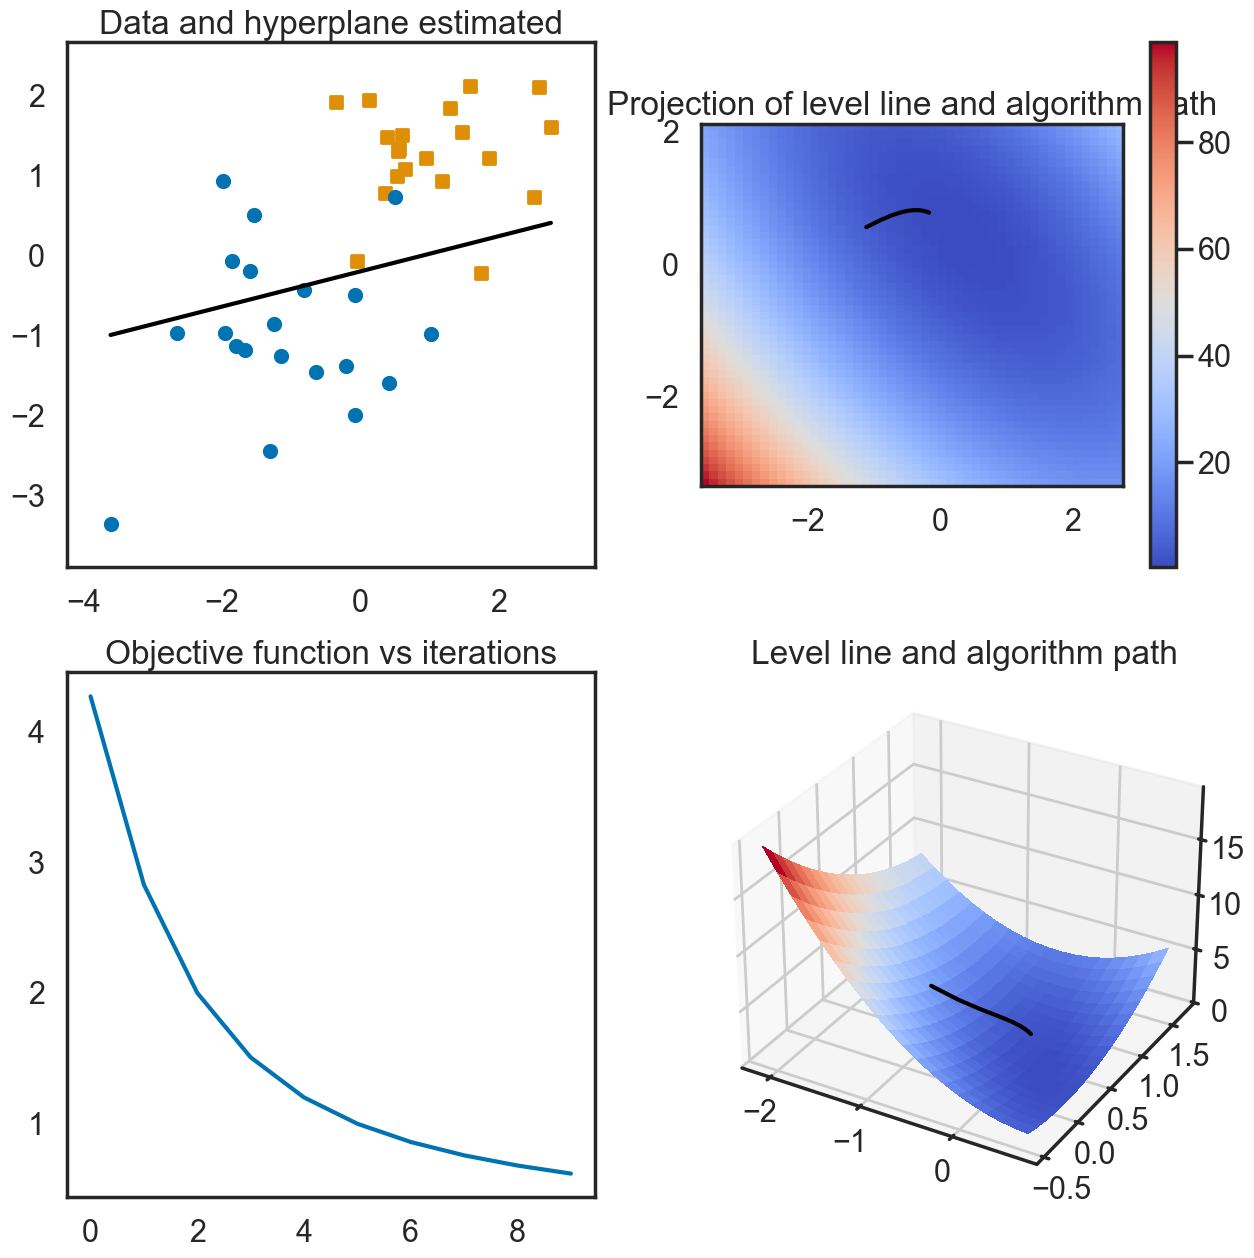

Text(0.5, 0.98, 'MSE and batch')

<Figure size 800x600 with 0 Axes>

In [22]:
plt.figure(7, figsize=(15, 15))
plot_gradient(X_bi_gauss, Y_bi_gauss, wh, cost_hist, loss_fun)
plt.suptitle('MSE and batch')

**Data and hyperplane estimated (Données et hyperplan estimé):** ce graphique montre un ensemble de données bidimensionnelles en deux classes (bleu et orange). La ligne noire est un hyperplan de décision qui a été estimé pour séparer les deux classes à l'aide de la fonction perte MSE.

**Objective function vs iterations (Fonction objectif vs itérations):** La décroissance de la valeur de la fonction objective ou la fonction de perte en fonction des itérations de l'algorithme. Une diminution de la fonction perte signifie une amélioration de la performance du modèle. Celà veut dire que la valeure prédite se rapproche de plus en plus de la valeur réelle. Cette amélioration est très forte au départ avant d'accroître petit à petit. Il est donc de plus en plus difficile d'avoir de bien prédire la valeur réelle.  

**Projection of level line and algorithm (Projection de la ligne de niveau et de l'algorithme):** Les deux axes représentent indifféremment les poids associés à chacune des variables d'entrées. Par conséquent, l'échelle de couleur représente les valeurs de la fonction objectif (ou fonction de perte) associées à chaque combinaison des paramètres du modèle. Les zones bleues correspondent à des valeurs plus basses de la fonction objectif. Ces zones indiquent des régions de l'espace des paramètres où le modèle a une meilleure performance. Inversement, les zones rouges correspondent à une performance moins bonne du modèle. La ligne noir montre le chemin parcouru par le gradient pour converger vers le minimimum de la fonction perte (les paramètres légèrement supérieures à 0). 

**Level line and algorithm path:** C'est pareil pour le troisième sous-graphique sauf qu'ici la représentation est en 3D.

### 5.2. Avec stochastique

eps = 0.05
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

La convergence dans le modèle stochastique présente un mouvement très **volatile** de la fonction de coût.  
Pourquoi cette trajectoire ? Je pense qu’il y a une raison valable à cela.

En effet, la formule du gradient de descente **stochastique** est la suivante :

$$
\theta := \theta - \eta \nabla_\theta \ell\left( \hat{f}_\theta(x_i), y_i \right)
$$

Ici, $\theta$ représente le vecteur de paramètres actuel du modèle, $\eta$ est le **taux d’apprentissage**, et  
$\nabla_\theta \ell(\hat{f}_\theta(x_i), y_i)$ est le **gradient** de la fonction de perte **par rapport à $\theta$**, calculé sur un seul exemple $(x_i, y_i)$.

Dans ce cas, **chaque mise à jour des paramètres est basée sur le gradient calculé pour un seul exemple**,  
ce qui signifie que la direction de la mise à jour est entièrement déterminée par cet exemple spécifique.  
Il peut ne pas représenter fidèlement la tendance générale des données.

> Cela explique pourquoi la trajectoire est très mouvementée :  
> on suit une pente différente à chaque exemple, ce qui cause des oscillations dans la descente.

---

Ce qui **n’est pas le cas** pour l’autre méthode, **le gradient batch**, qui repose sur la moyenne :

$$
\frac{1}{n} \sum_{i=1}^n \ell\left( f_w(x_i), y_i \right)
$$

Dans ce cas, chaque mise à jour du vecteur de poids $w$ utilise l’information de **toutes les données disponibles**,  
ce qui rend la **convergence beaucoup plus lisse**.

# 6. Expérimentations avec stochastique

Pour profiter pleinement de ce passage, on fait aussi une simulation avec le facteur multiplicatif au départ avant de procéder au changement des variables.

## 6.1. simulation du facteur multiplicatif de descente espilone

### 6.1.1. Diminution

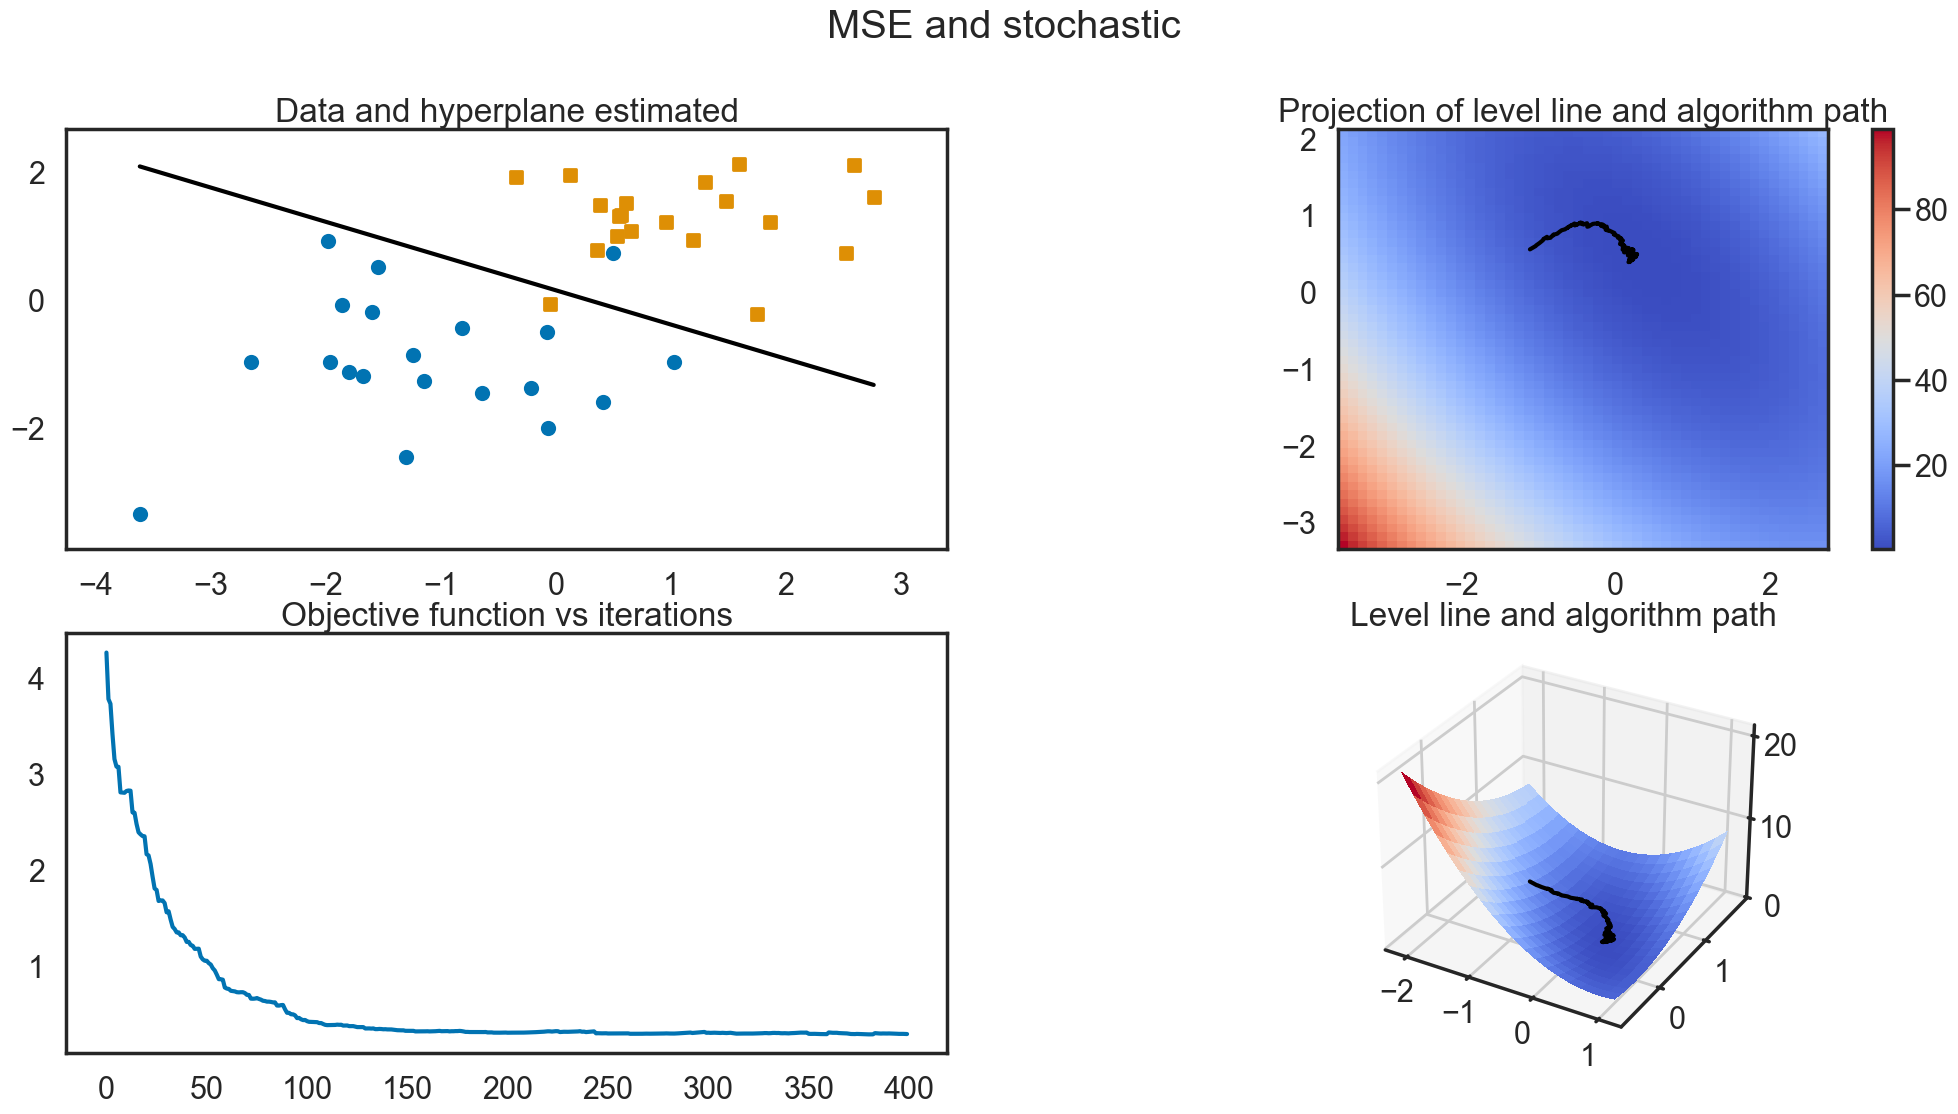

In [31]:
eps = 0.005
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

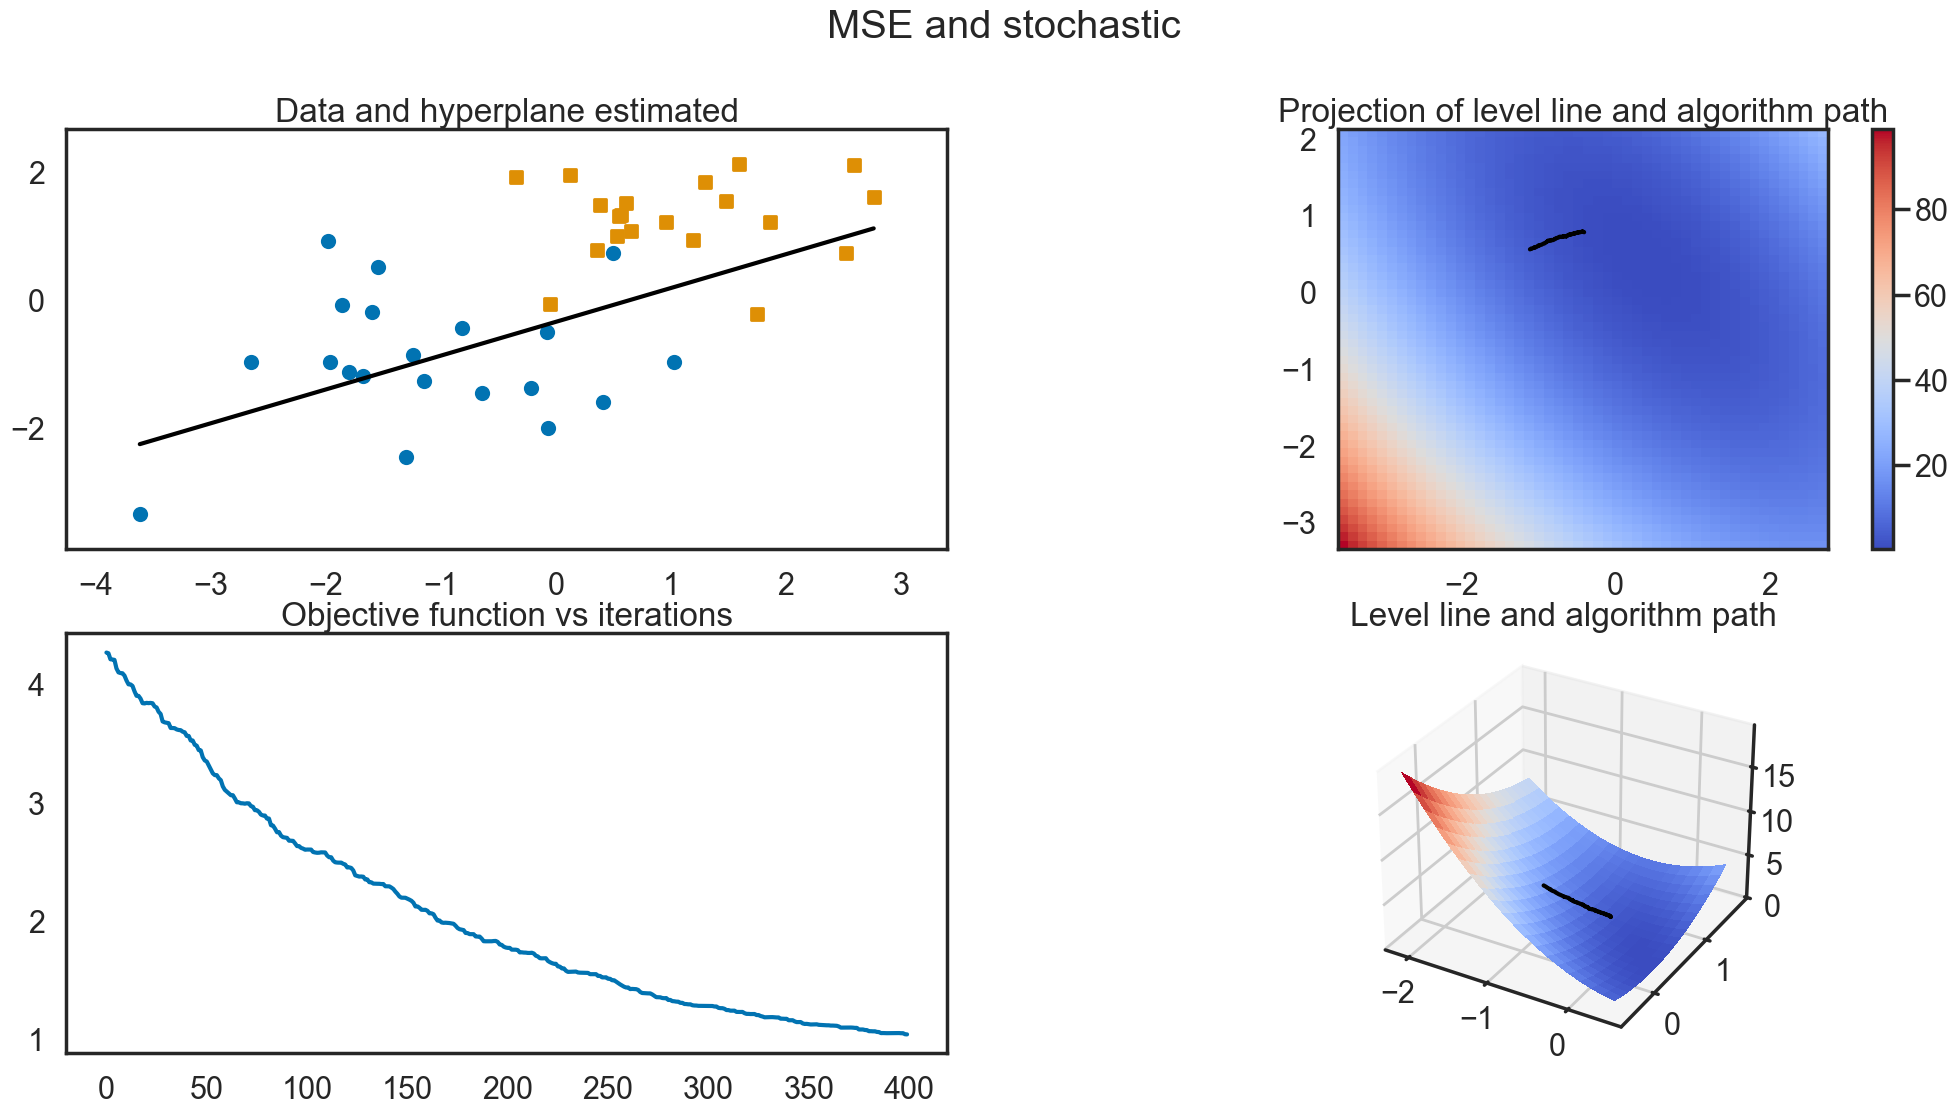

In [33]:
eps = 0.0005
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

Quand on diminue le facteur multiplicatif de la descente,  l'évolution de la fonction objective est devenue lisse avec un accroissement du nombre d'itérations. 

### 6.1.2. Augmentation

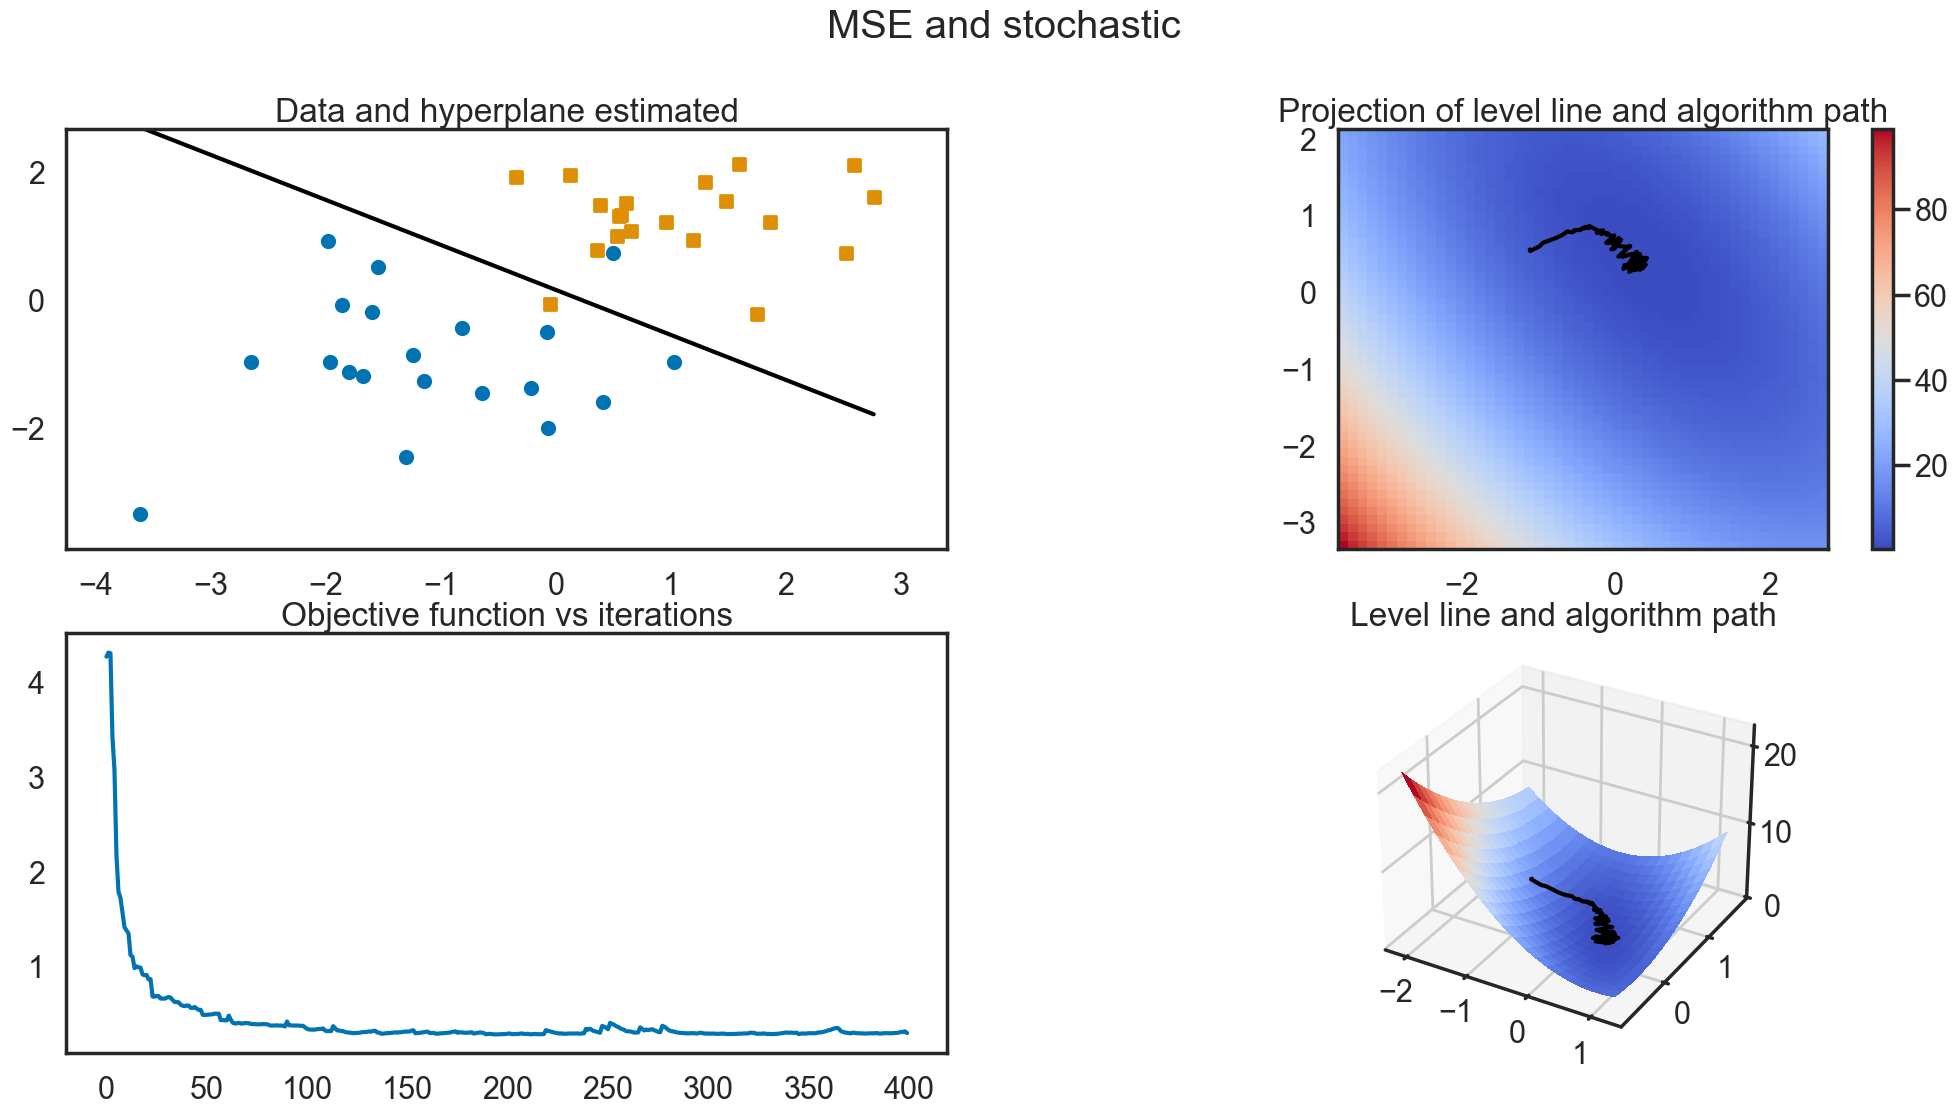

In [36]:
eps = 0.01
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

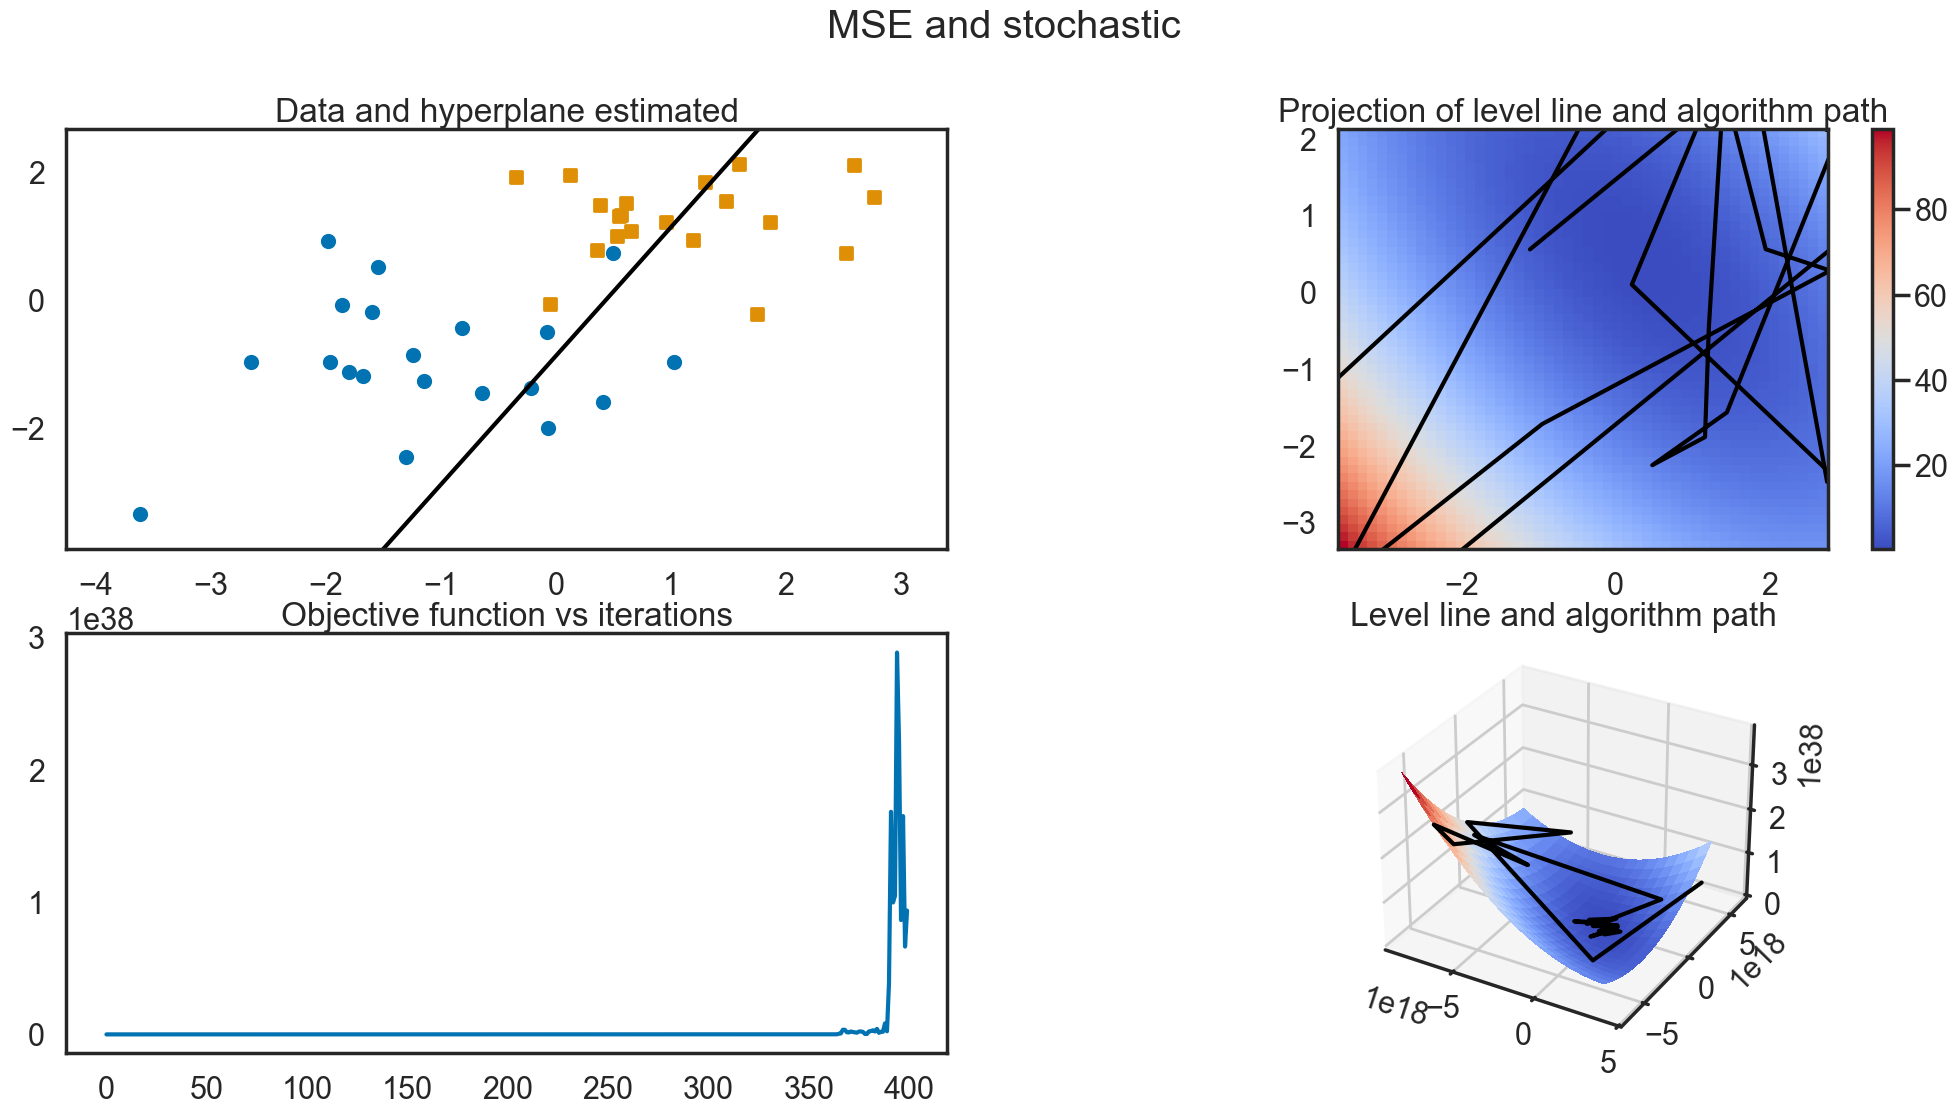

In [38]:
eps = 0.25
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

D:\Télécom_Paris\Machine_learning_1\3-Classification\TP_perceptron\tp_perceptron_source.py:213: RuntimeWarning: overflow encountered in square
  return (y - predict(x, w)) ** 2
C:\Users\Mita\anaconda3\envs\portofolio\lib\site-packages\mpl_toolkits\mplot3d\proj3d.py:177: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w


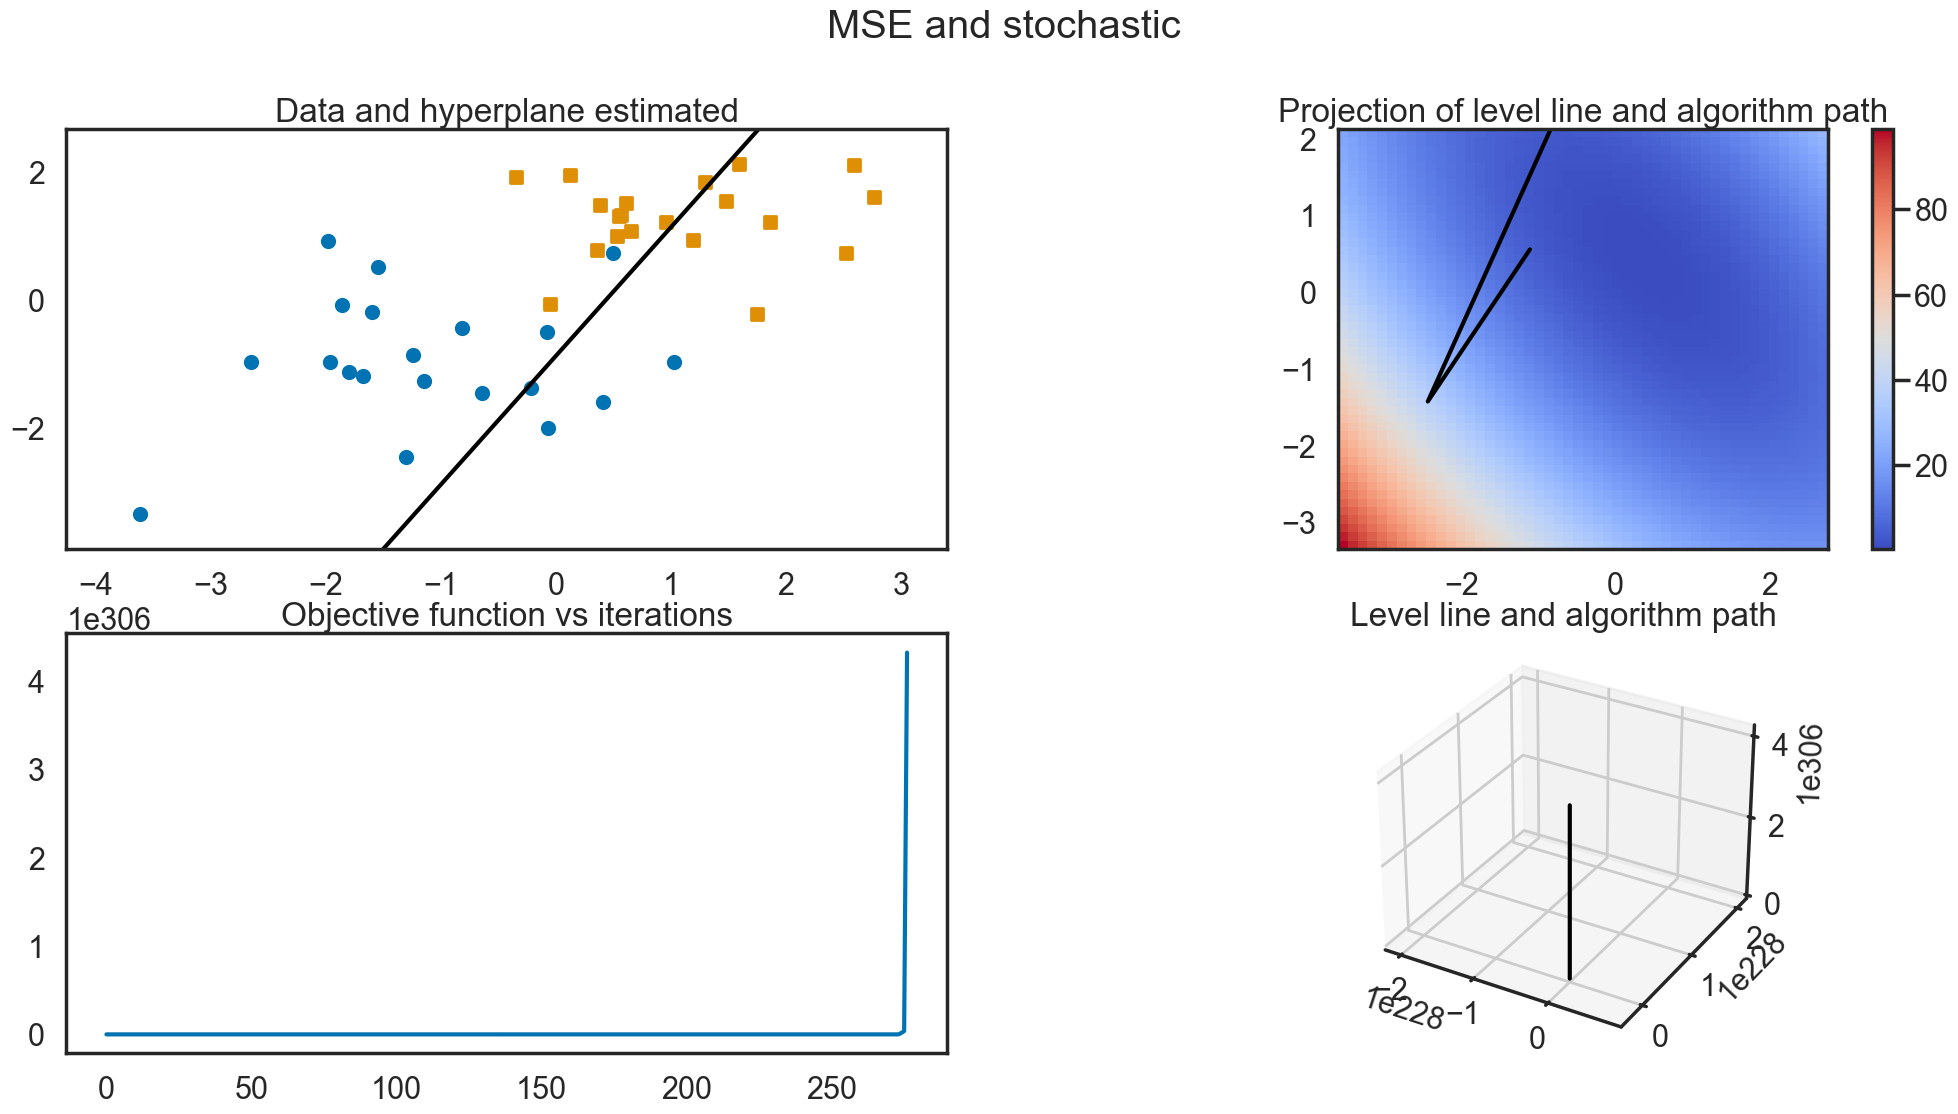

In [40]:
eps = 1
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

Nous avons détecté un comportement étrange. Lorsqu'on augmente le facteur multiplicatif de la descente, à un certain seuil(alentour de 2.5), le nombre d'itération n'a plus de pouvoir d'amélioration de la performance du modèle. Pire, Si le nombre d'itération fait varier la performance, il le fait d'une manière négative. eps = 1 par exemple fait augmenter significativement la perte à partir de 400 itérations. 

Par ailleurs, plus on augmente le facteur multiplicatif, moins il y a de nombre d'itérations à franchir pour que la performance se dégrade. Dans un epsilone = 1, on n'a besoin que 300 itérations pour faire dégrader la performance.

Cette évolution n'a rien d'anormal si l'on revienne sur l'évolution de la courbe de la fonction perte en fonction des poids. 
En effet, epsilone est le pas de l'itération tout au long de la courbe de fonction perte pour se converger jusqu'au minimum. Si epsilone est très grand, ce pas ne permet pas à l'algorithme de se converger. Le pas fait en sorte qu'on saute directement le minimum pour aller vers l'autre partie du graphe. Plus ce saut est élevé, plus il est facile d'aller vers des valeurs de la fonction objective plus élevé qu'on a vu auparavant.

En voyant cette évolution, il est tentant de penser qu'il fallait aussi simuler des valeurs très petites d'epsillone.

### 6.1.3 Retour à la diminution

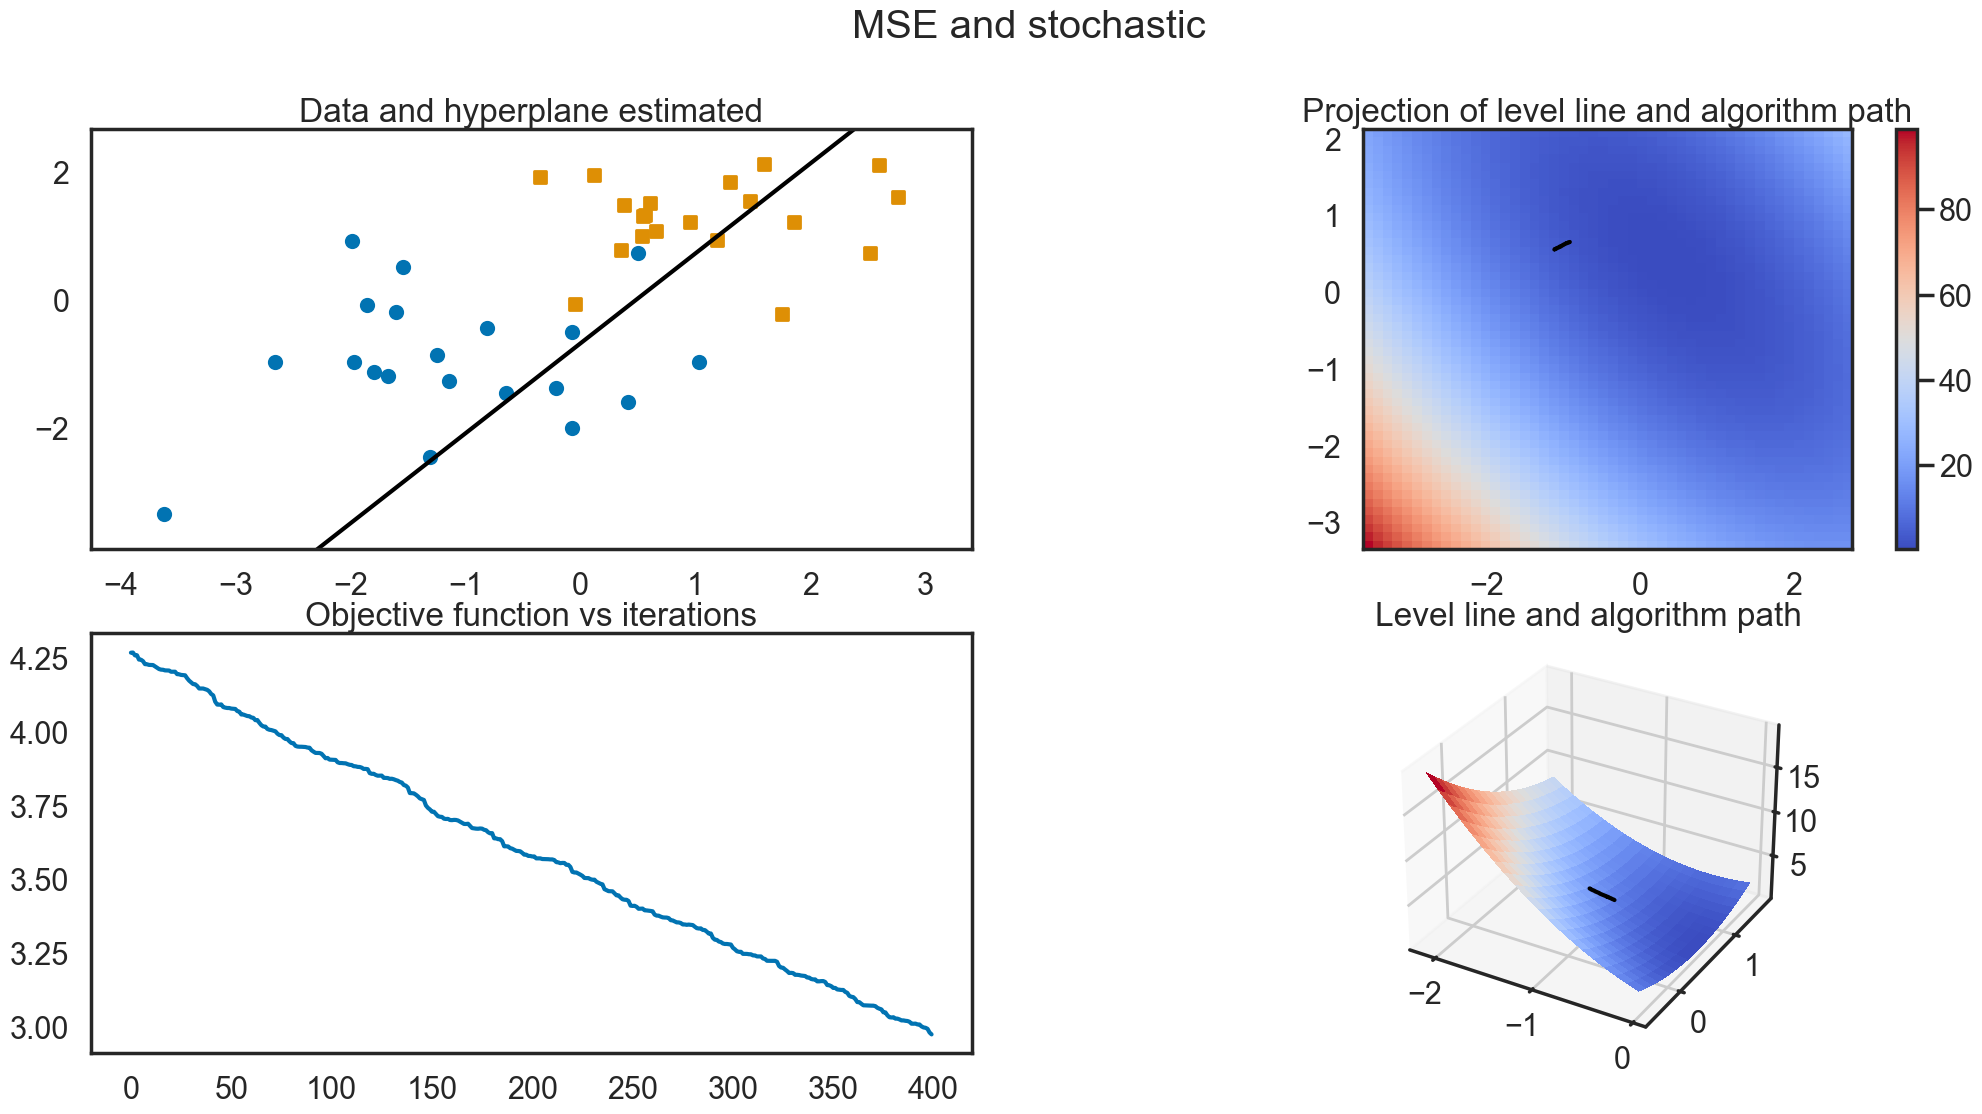

In [44]:
eps = 0.0001
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

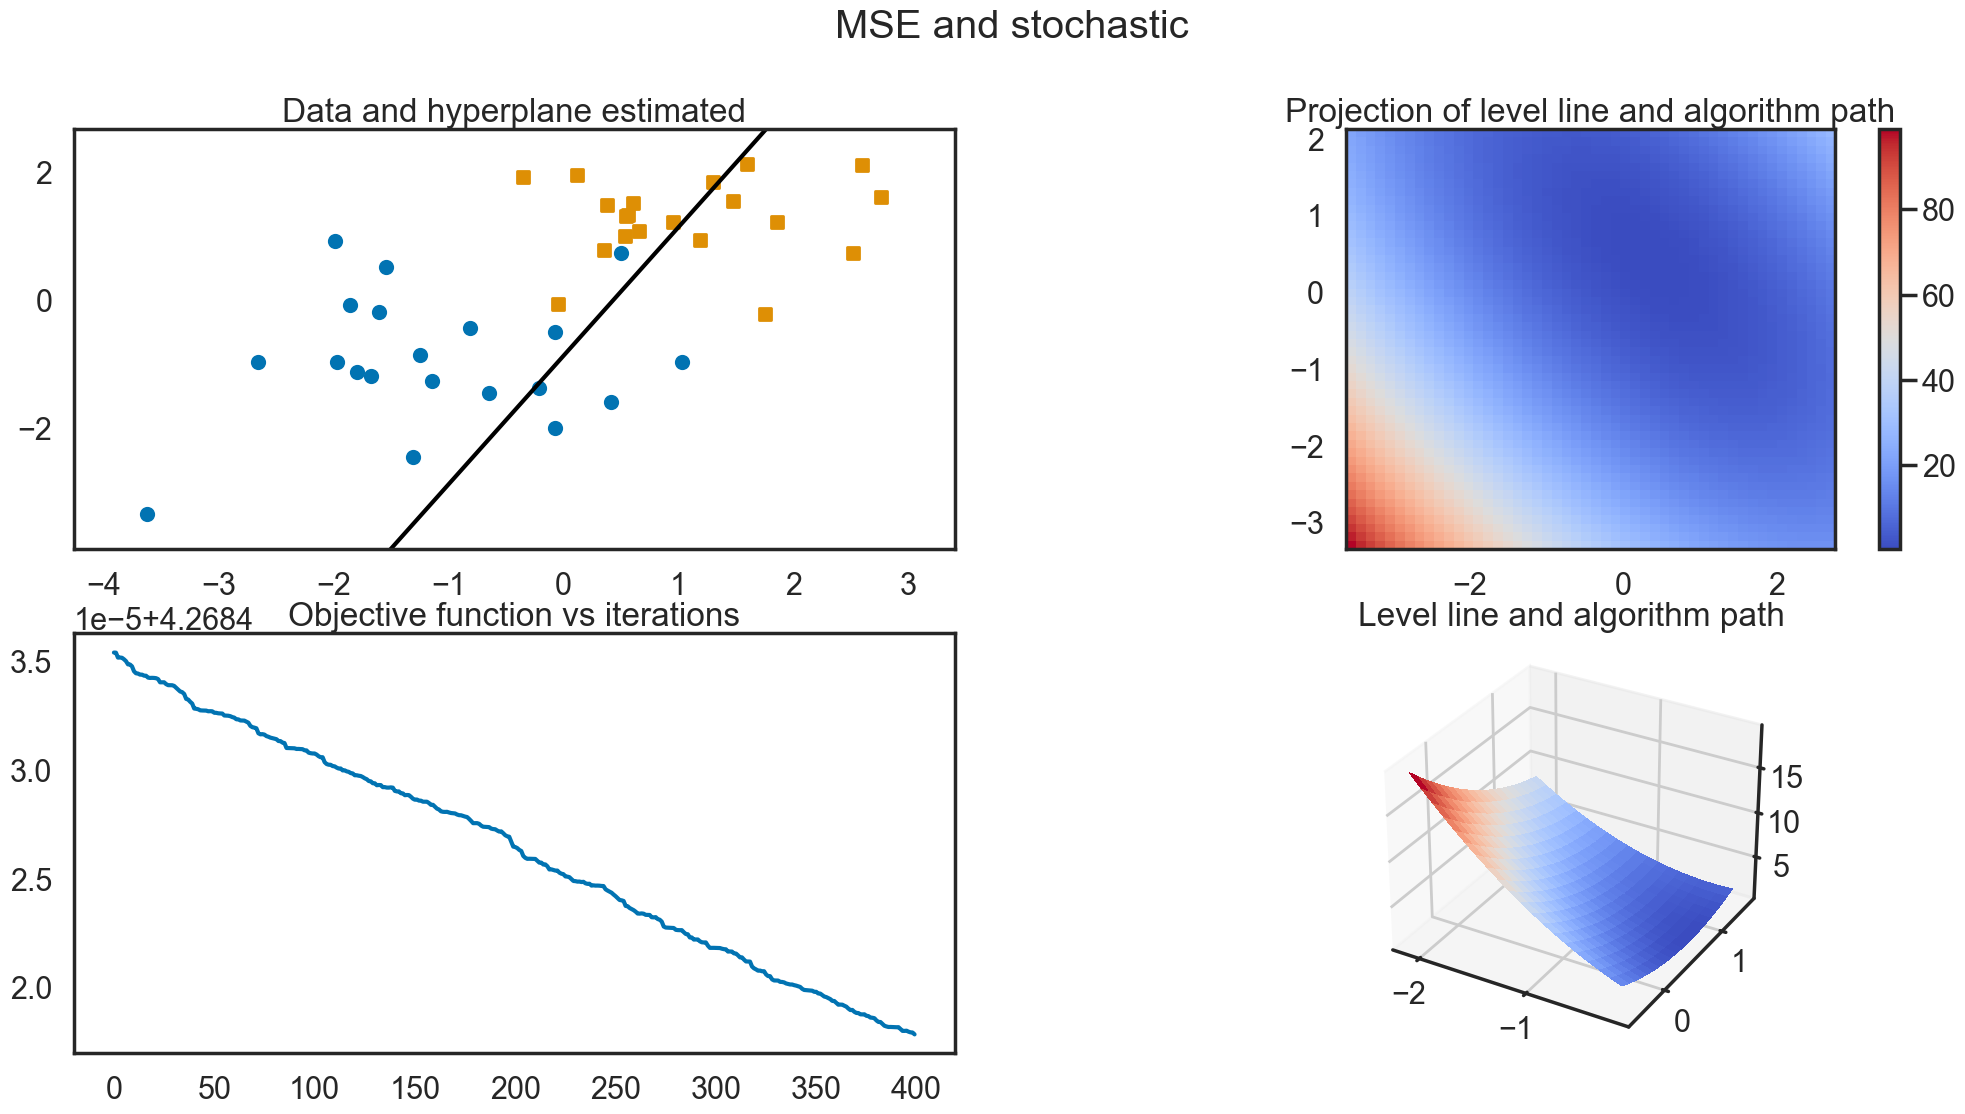

In [46]:
eps = 0.000000001
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

Comme dans des valeurs très élevées de epsilone, il n'y a pas non plus une convergence à espérer dans le cas où epsilone est très faible. Pourtant, la raison est différent.

Lorsque le pas d'itération est très petit, il y a convergence dans un temps infini. Pratiquement, l'itération s'arrête à un moment donné. Elle devient juste un petit point dans l'espace de convergence.

Empiriquement, on a prouvé que le pas de descente est crucial dans le cadre du gradient descent stochastique. Il faut trouver le juste milieu pour ne pas rater le minimimum. Pas trop grand, pas trop petit, il faut un pas juste. Dans la pratique, on combine le grand pas et le petit pas pour respectivement sauter et gagner en précision après.

### 6.2. Simulation avec la difficulté de classification de données (nature des données)

#### 6.2.1. simulation avec d'autres types de données

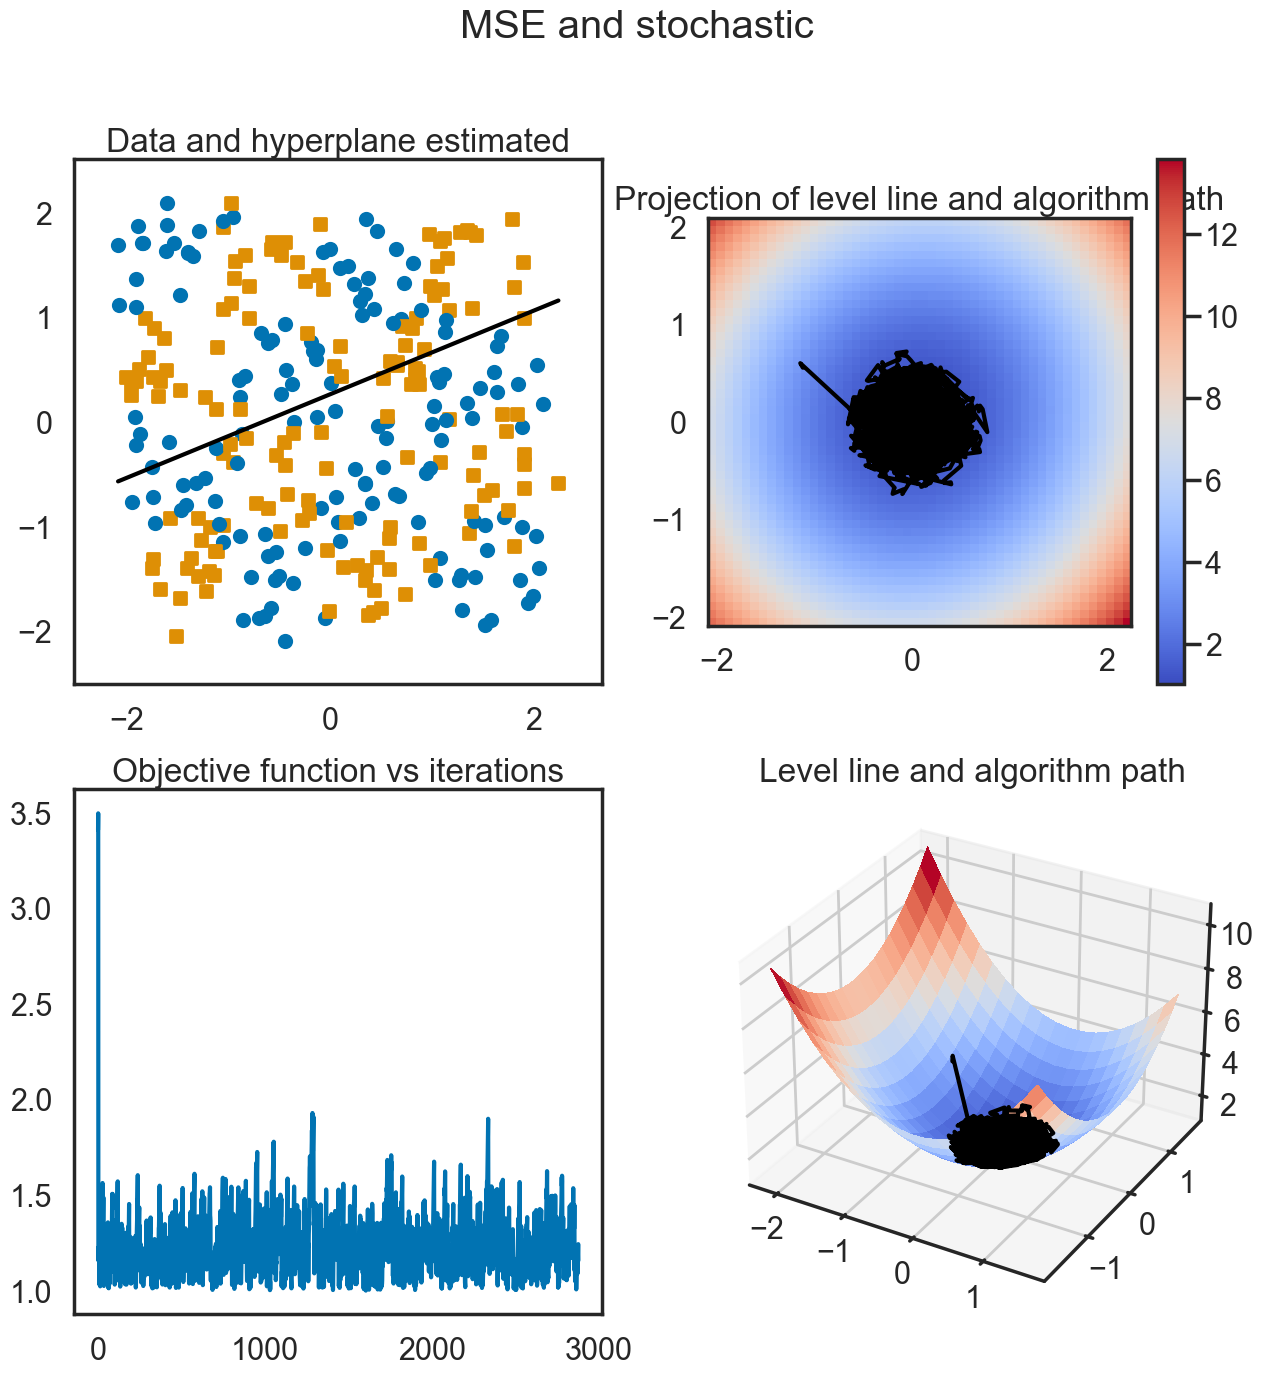

In [48]:
eps = 0.05
plt.figure(8, figsize=(15, 15))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_chekers, Y_chekers, eps, niter * len(Y_chekers), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_chekers, Y_chekers, wh_sto, costh_sto, loss_fun)

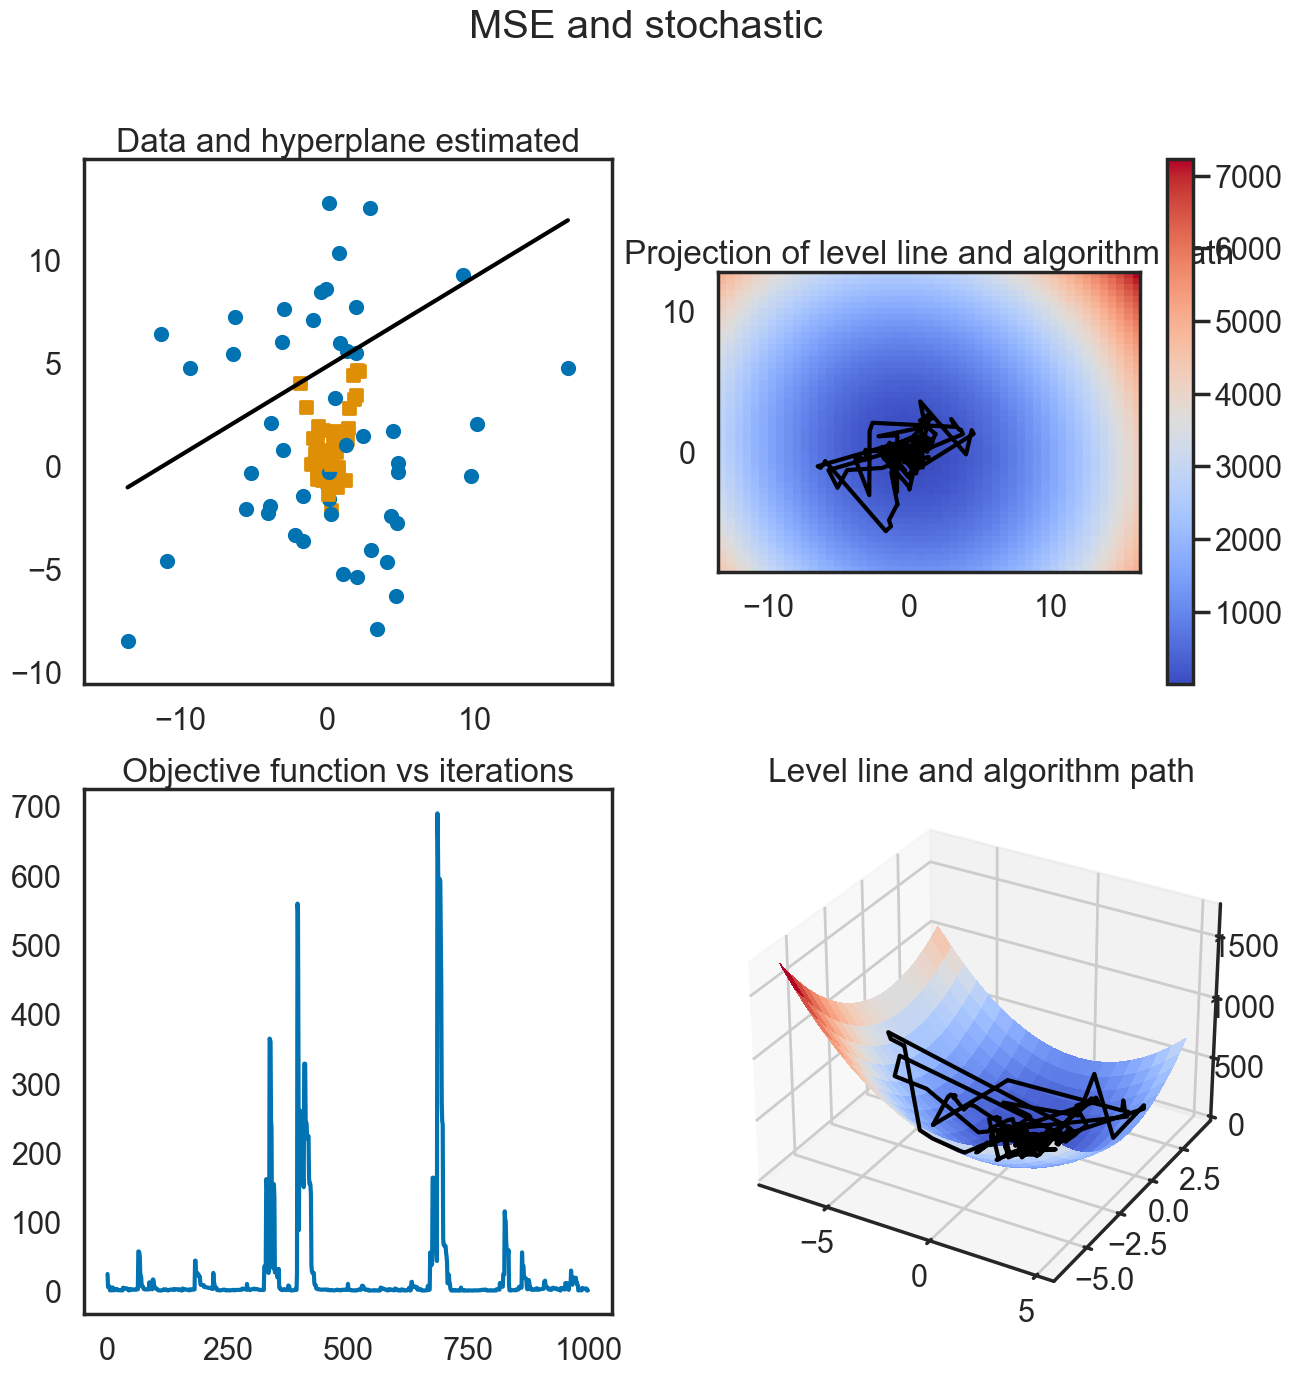

In [50]:
eps = 0.01
plt.figure(8, figsize=(15, 15))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_clown, Y_clown, eps, niter * len(Y_clown), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_clown, Y_clown, wh_sto, costh_sto, loss_fun)

Nous avons ici deux jeux de données dont les classes sont inséparables par une droite. Qu'est-ce qu'on observe? 

Nous voyons très bien que la droite ne sépare pas les deux classes. Leur valeur part dans tous les sens pour essayer de minimiser la fonction coût. Ce n'est pas au hasard s'il y a une échelle de variation notable dans les deux données. Dans les données chekers, on constate une variation entre 1.0 à 1.8. Dans les données clown, on voit une explosion de la fonction perte au départ et gardant une stabilité après. Il faut nuancer cette stabilité puisque la suite de la courbe n'est pas très visible après le pic. En voyant les autres sous-graphiques, on peut dire que la volatilité est la règle. 

Ce qui est étonnant c'est que l'algorithme arrive quand même à tracer une droite alors que les données ne sont s'y apprêtent pas. C'est possible puisque quelques soit le type de données à analyser, il y a toujours des valeurs de poids qui minimisent la fonction de décision. Algébriquement c'est correct mais graphiquement c'est loin d'être pertinent.

### 6.3. Simulation avec d'autres fonctions pertes pour les données gaussiennes

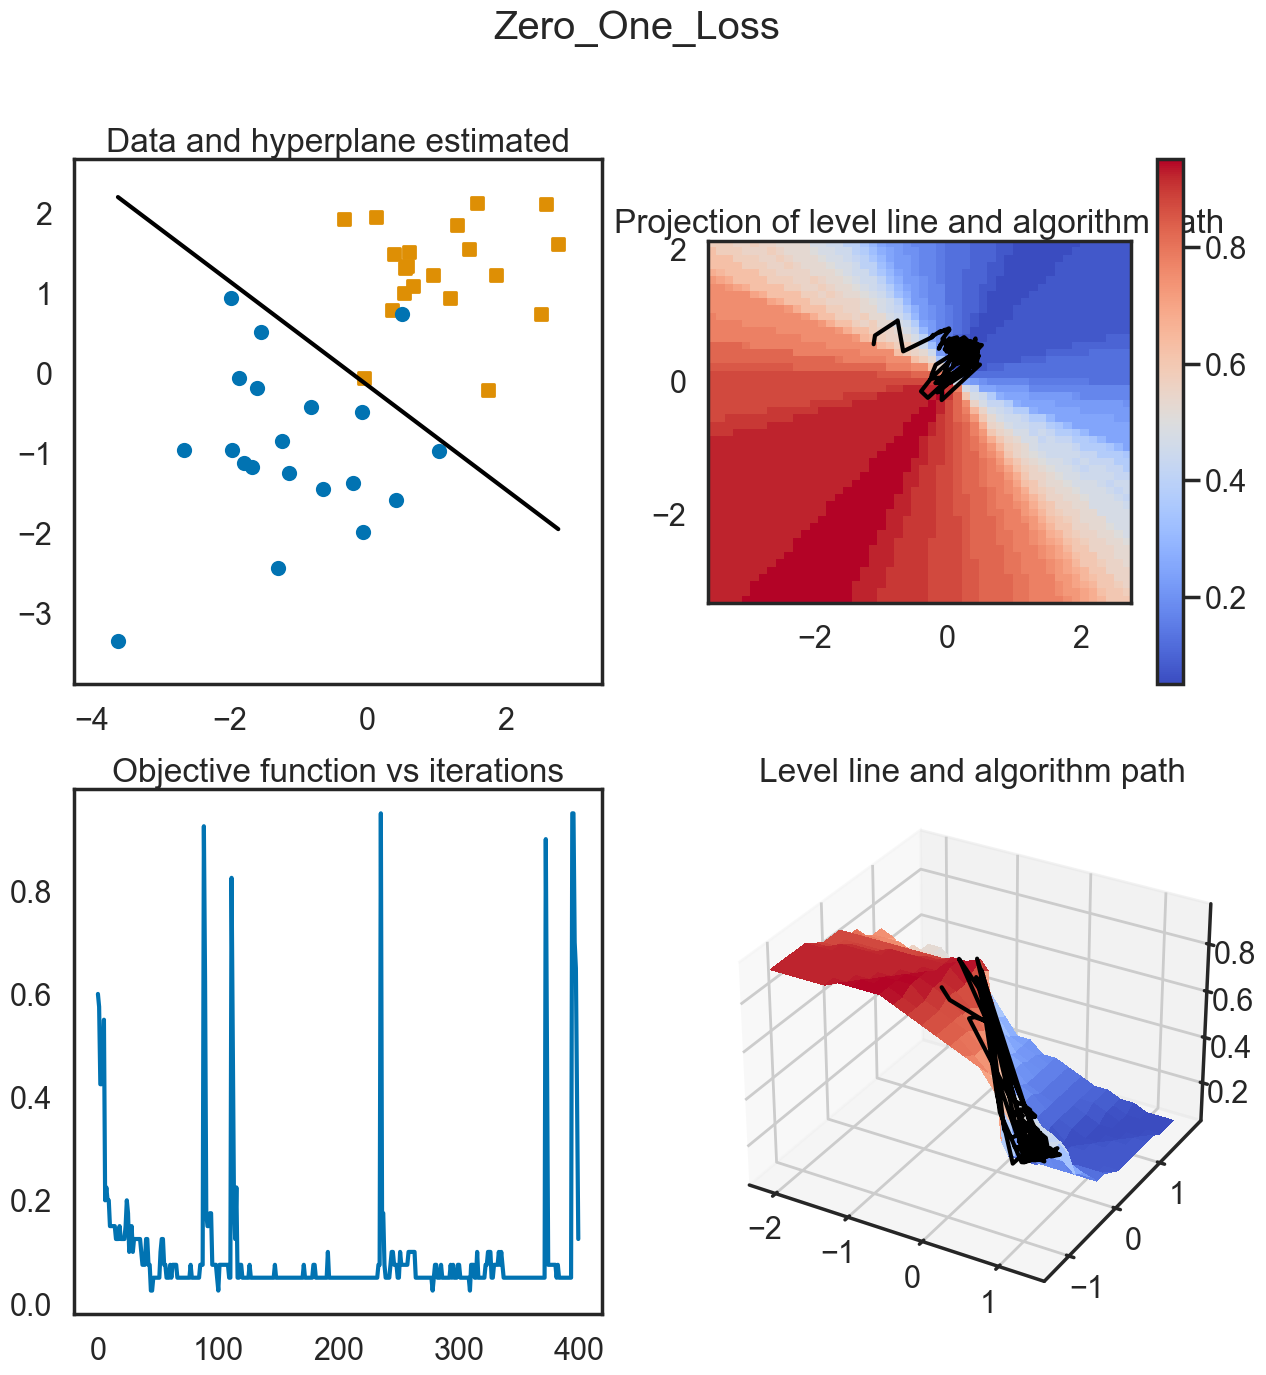

In [53]:
eps = 0.05
loss_fun = zero_one_loss
plt.figure(8, figsize=(15, 15))
plt.suptitle('Zero_One_Loss')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

In [54]:
print(wh_sto)

[[ 0.48512599 -1.11770877  0.5557001 ]
 [ 0.38929628 -1.09722432  0.68775246]
 [ 0.57026089 -0.76087784  0.90888056]
 ...
 [ 0.01434375 -0.24125973  0.09646629]
 [ 0.11297165 -0.18149588  0.2452975 ]
 [-0.00333458  0.02752365  0.37620114]]


On arrive à une même séparation que dans la méthode MSE. Par contre, la manière d'y arriver est totalement divergent.
Par rapport à l'évolution des poids, on voit qu'il y ne changent pas beaucoup (sous-graphique 2). Dans le MSE, l'échelle est très grand pour capturer leur variation (0 à 50) alors qu'ici on a une échelle très faible (0 à 0.8). En conséquence, la valeur de la fonction objective l'est aussi.
S'agissant de la fonction objective, sa variation est constante par morceaux. C'est normal comme l'évolution de zero one-loss ci-dessus. 

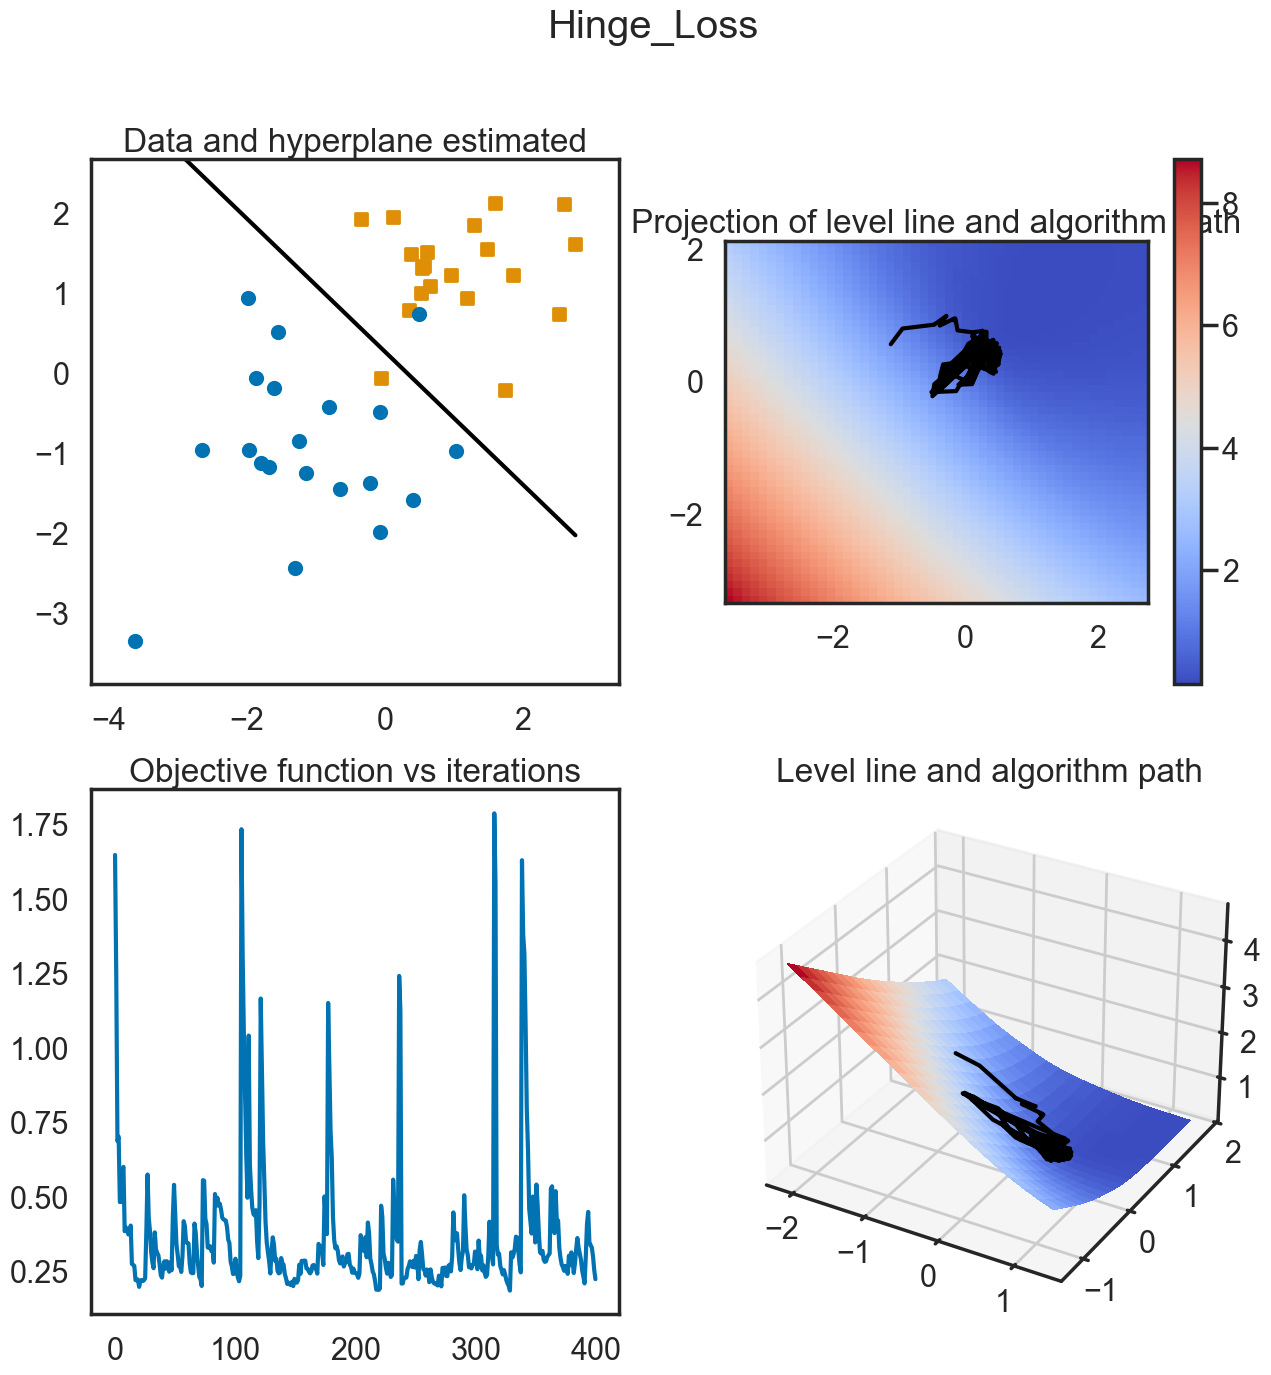

In [57]:
eps = 0.05
loss_fun = hinge_loss
plt.figure(8, figsize=(15, 15))
plt.suptitle('Hinge_Loss')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

On s'attend à une évolution semblable à MSE. Chose non faite.

## 7. Etude de l'algorithme de descente gradient classique

### 7.1. simulation du facteur multiplicatif de descente

#### 7.1.1. Diminution

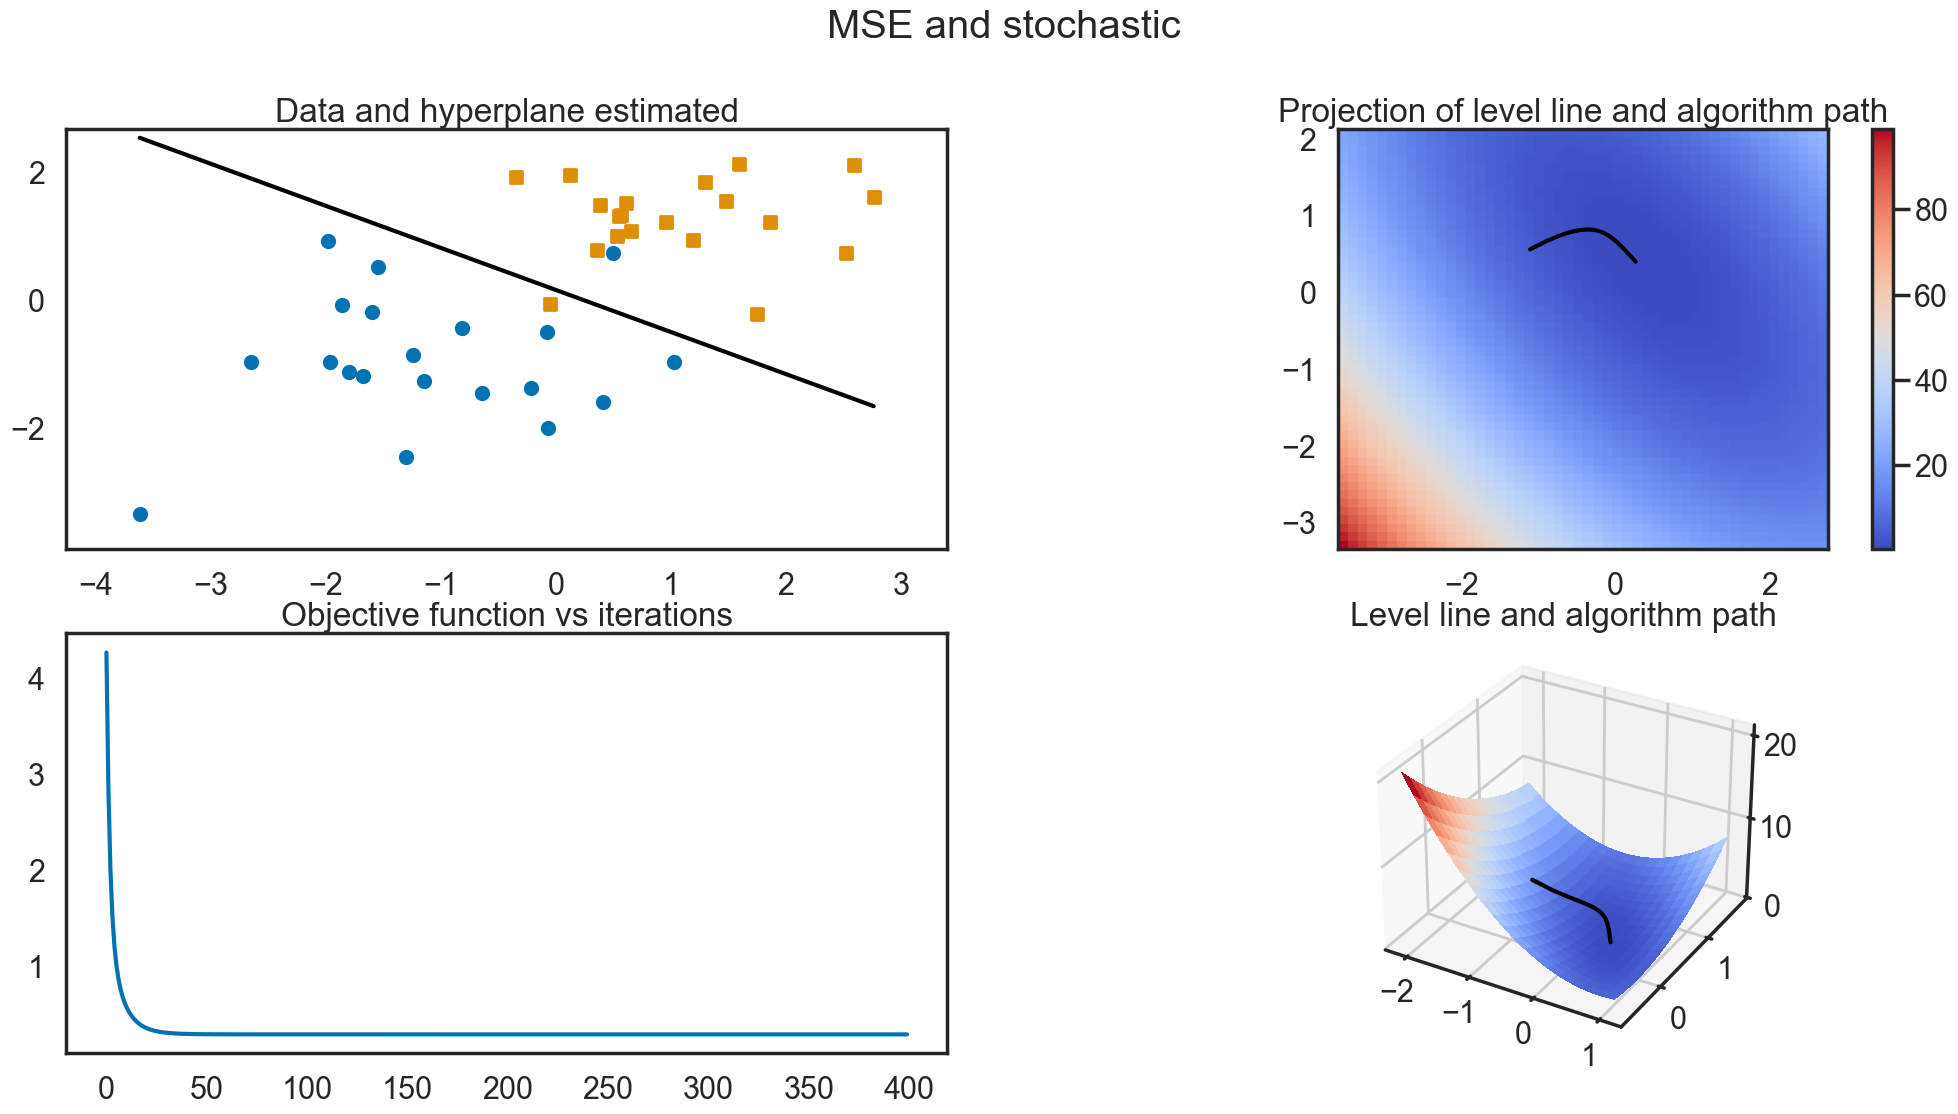

In [61]:
eps = 0.001
loss_fun = mse_loss
plt.figure(7, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=False)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

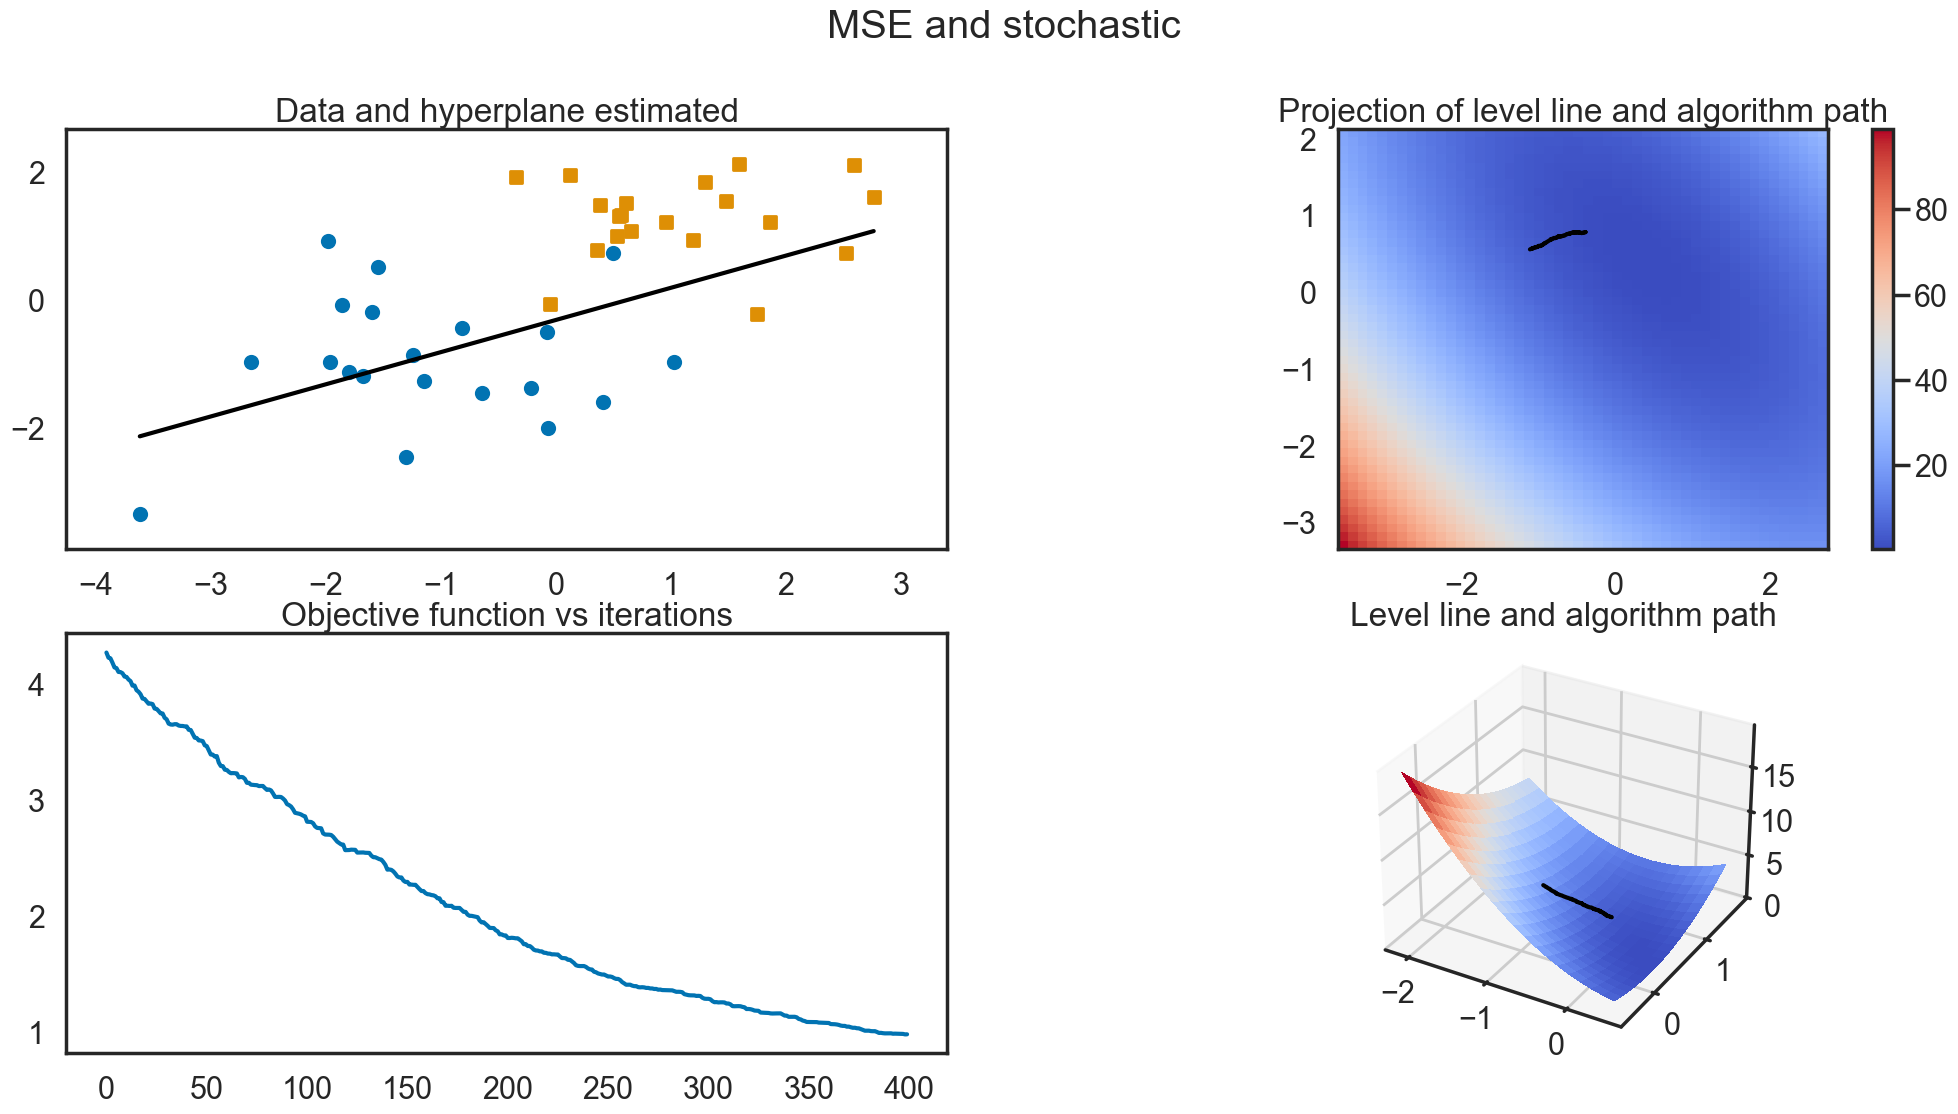

In [63]:
eps = 0.0005
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

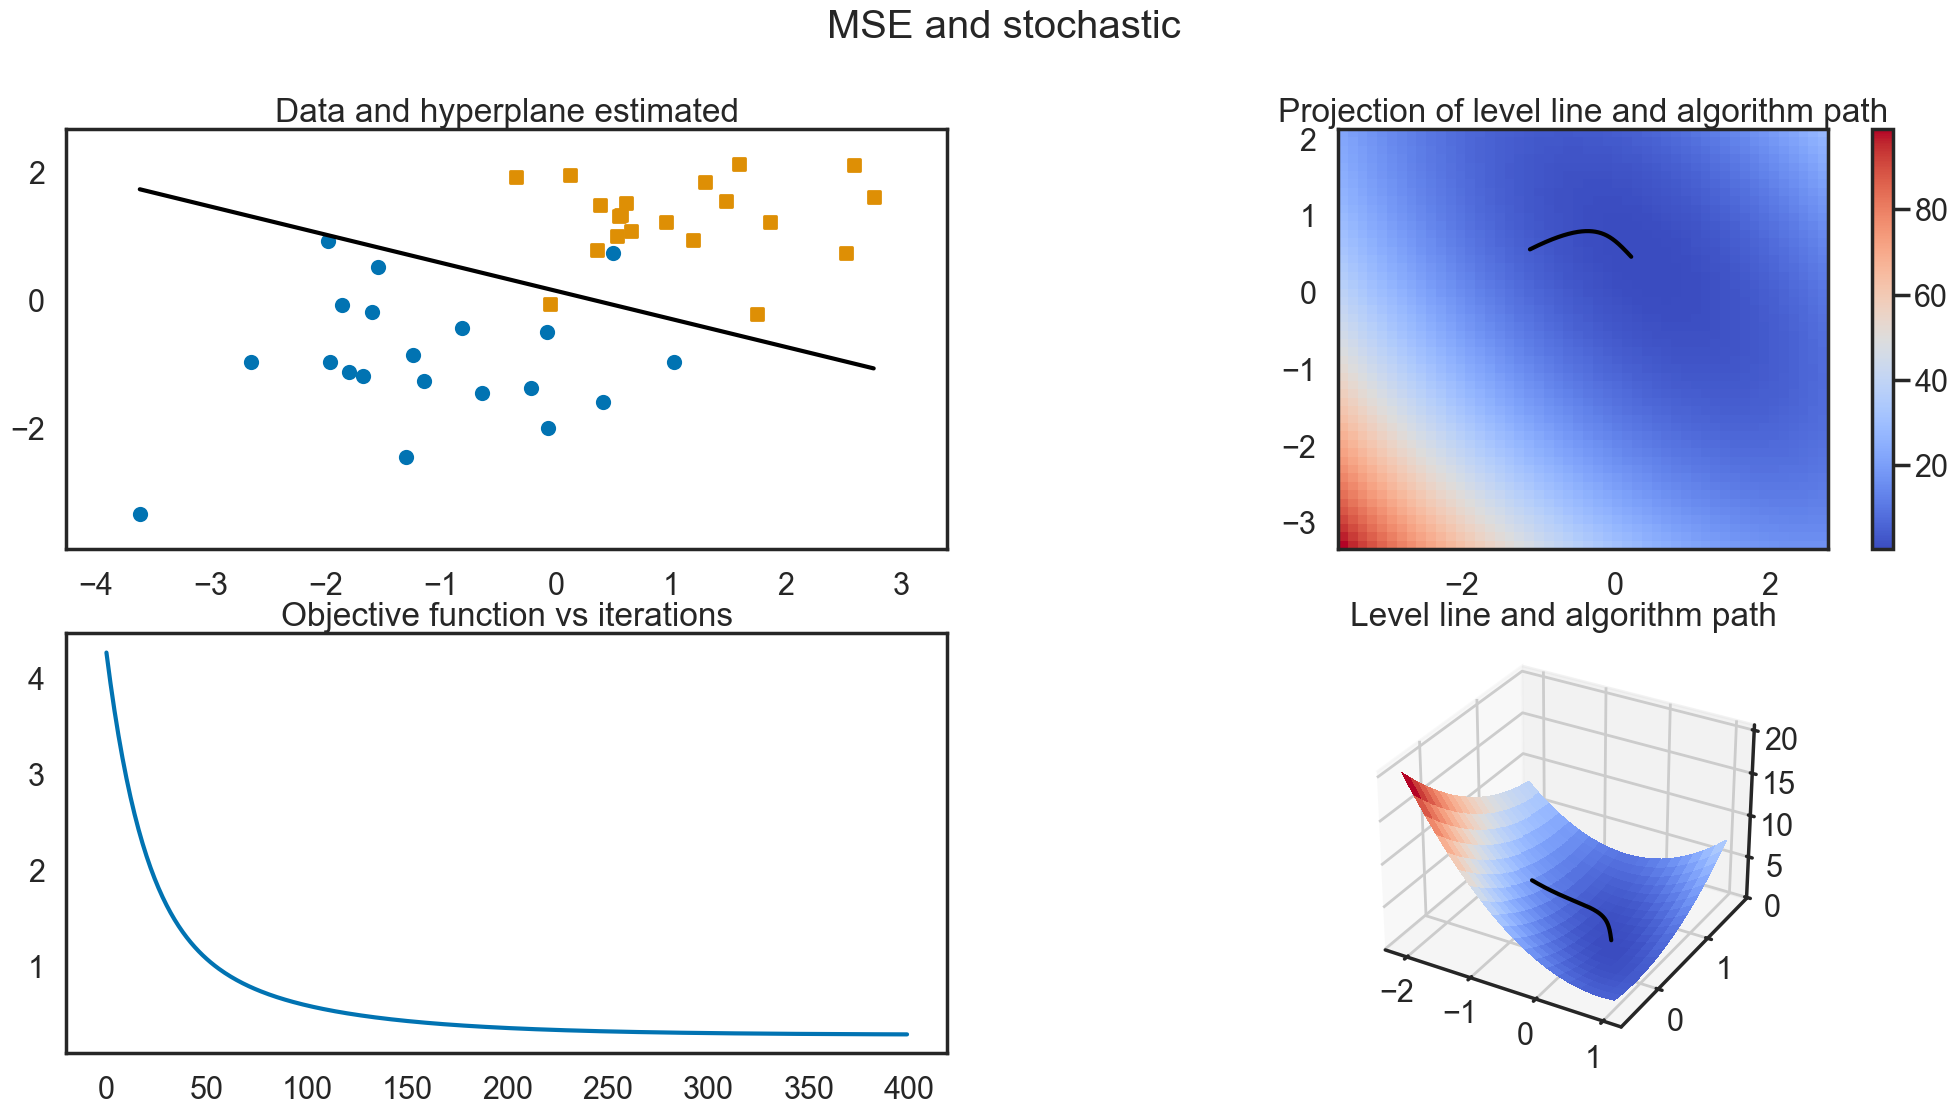

In [65]:
eps = 0.0001
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=False)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

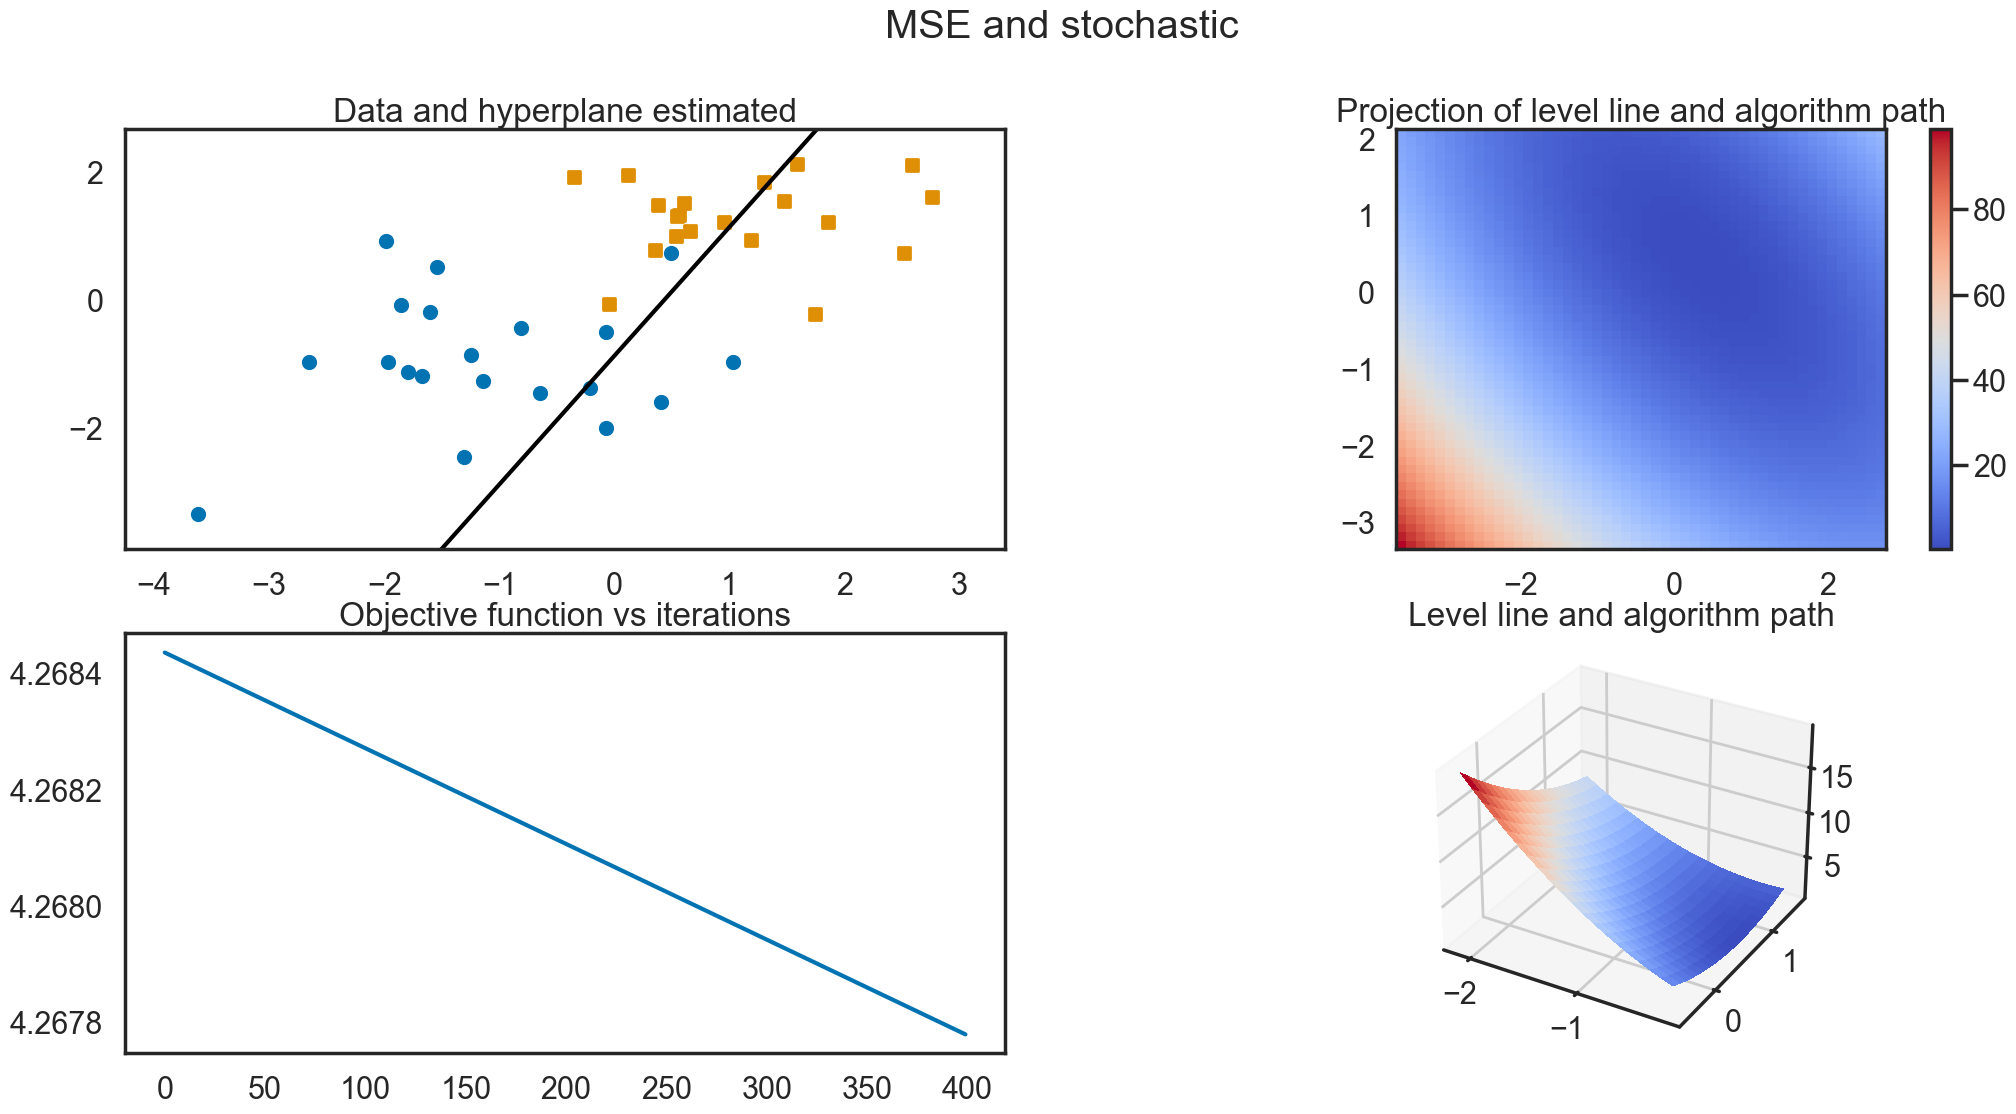

In [68]:
eps = 0.000000001
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=False)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

#### 7.1.1. Augmentation

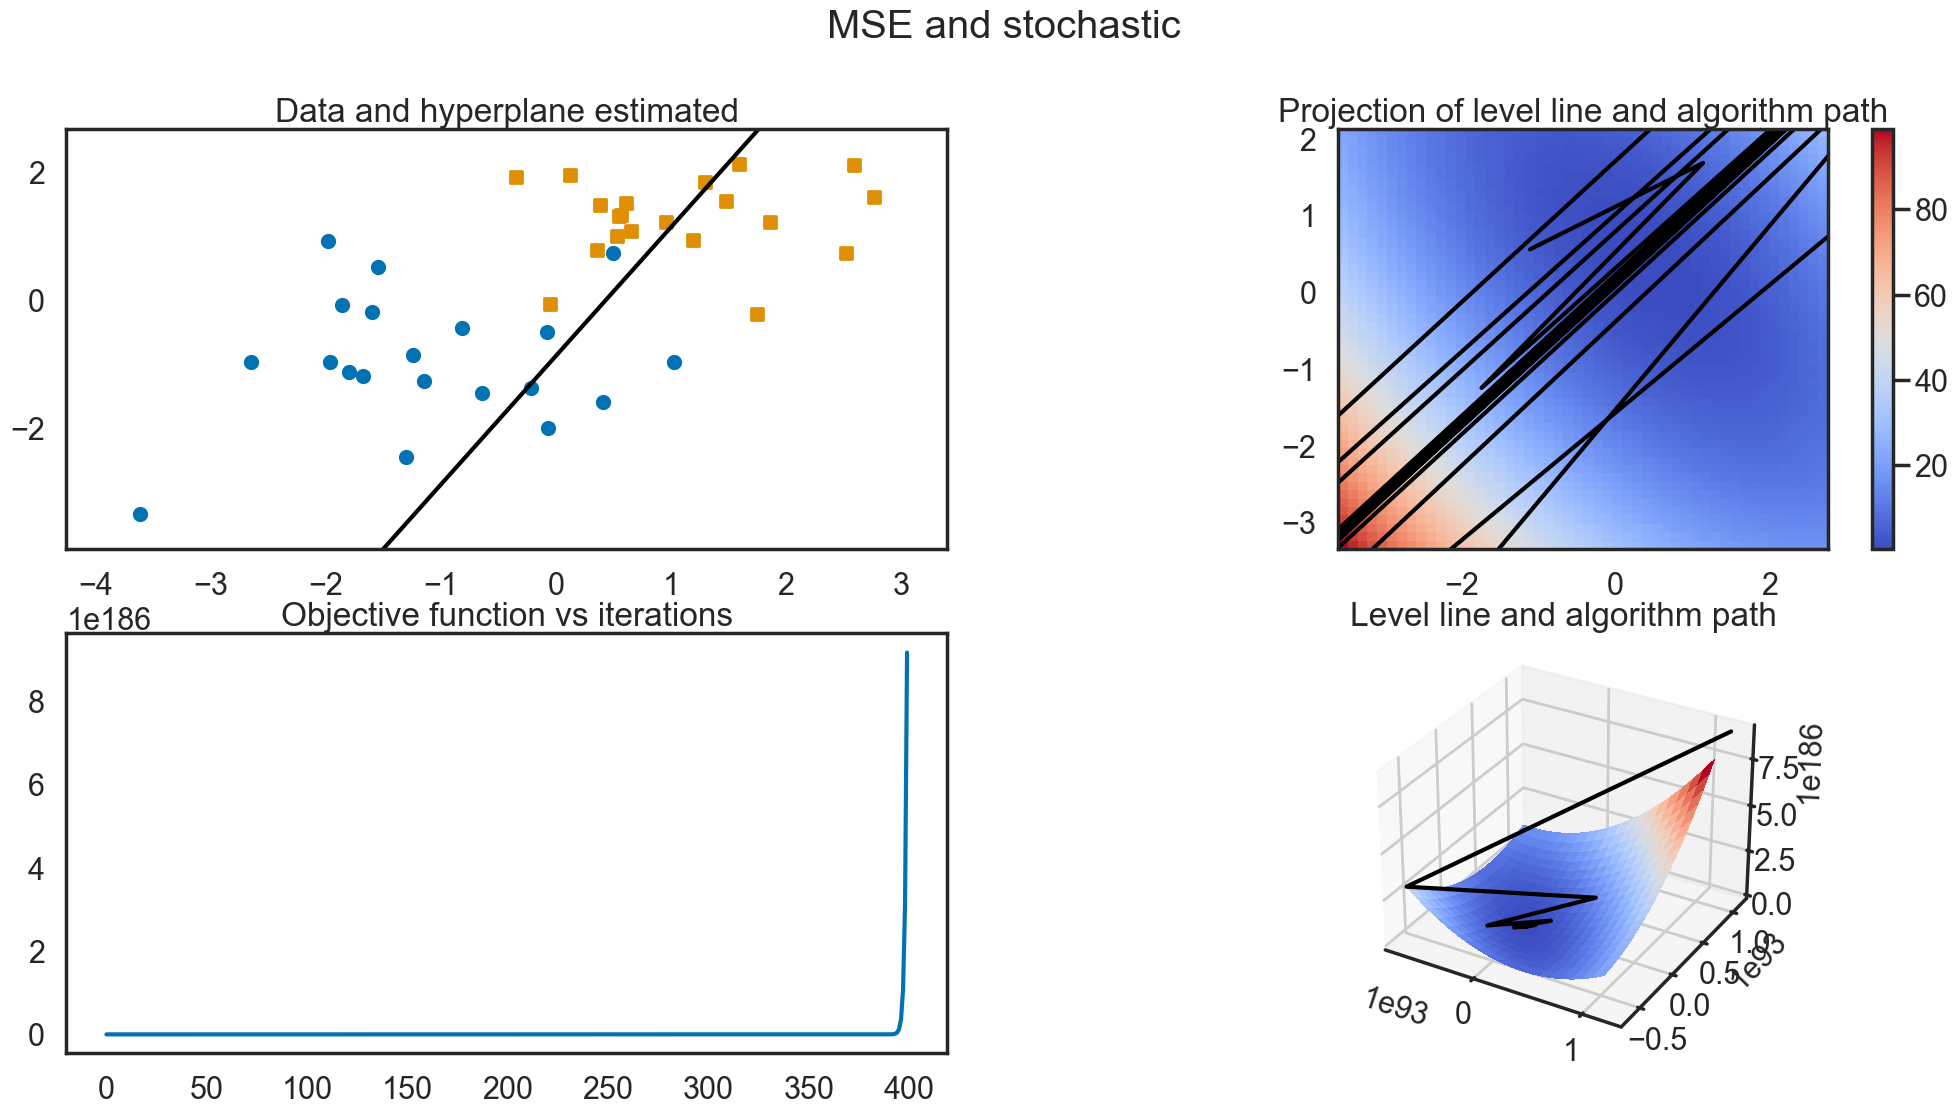

In [69]:
eps = 0.01
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=False)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

C:\Users\Mita\anaconda3\envs\portofolio\lib\site-packages\numpy\_core\_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
D:\Télécom_Paris\Machine_learning_1\3-Classification\TP_perceptron\tp_perceptron_source.py:213: RuntimeWarning: overflow encountered in square
  return (y - predict(x, w)) ** 2
D:\Télécom_Paris\Machine_learning_1\3-Classification\TP_perceptron\tp_perceptron_source.py:182: RuntimeWarning: invalid value encountered in scalar divide
  [min_tot0 * -w[1] / w[2] - w[0] / w[2],
D:\Télécom_Paris\Machine_learning_1\3-Classification\TP_perceptron\tp_perceptron_source.py:183: RuntimeWarning: invalid value encountered in scalar divide
  max_tot0 * -w[1] / w[2] - w[0] / w[2]],


ValueError: arange: cannot compute length

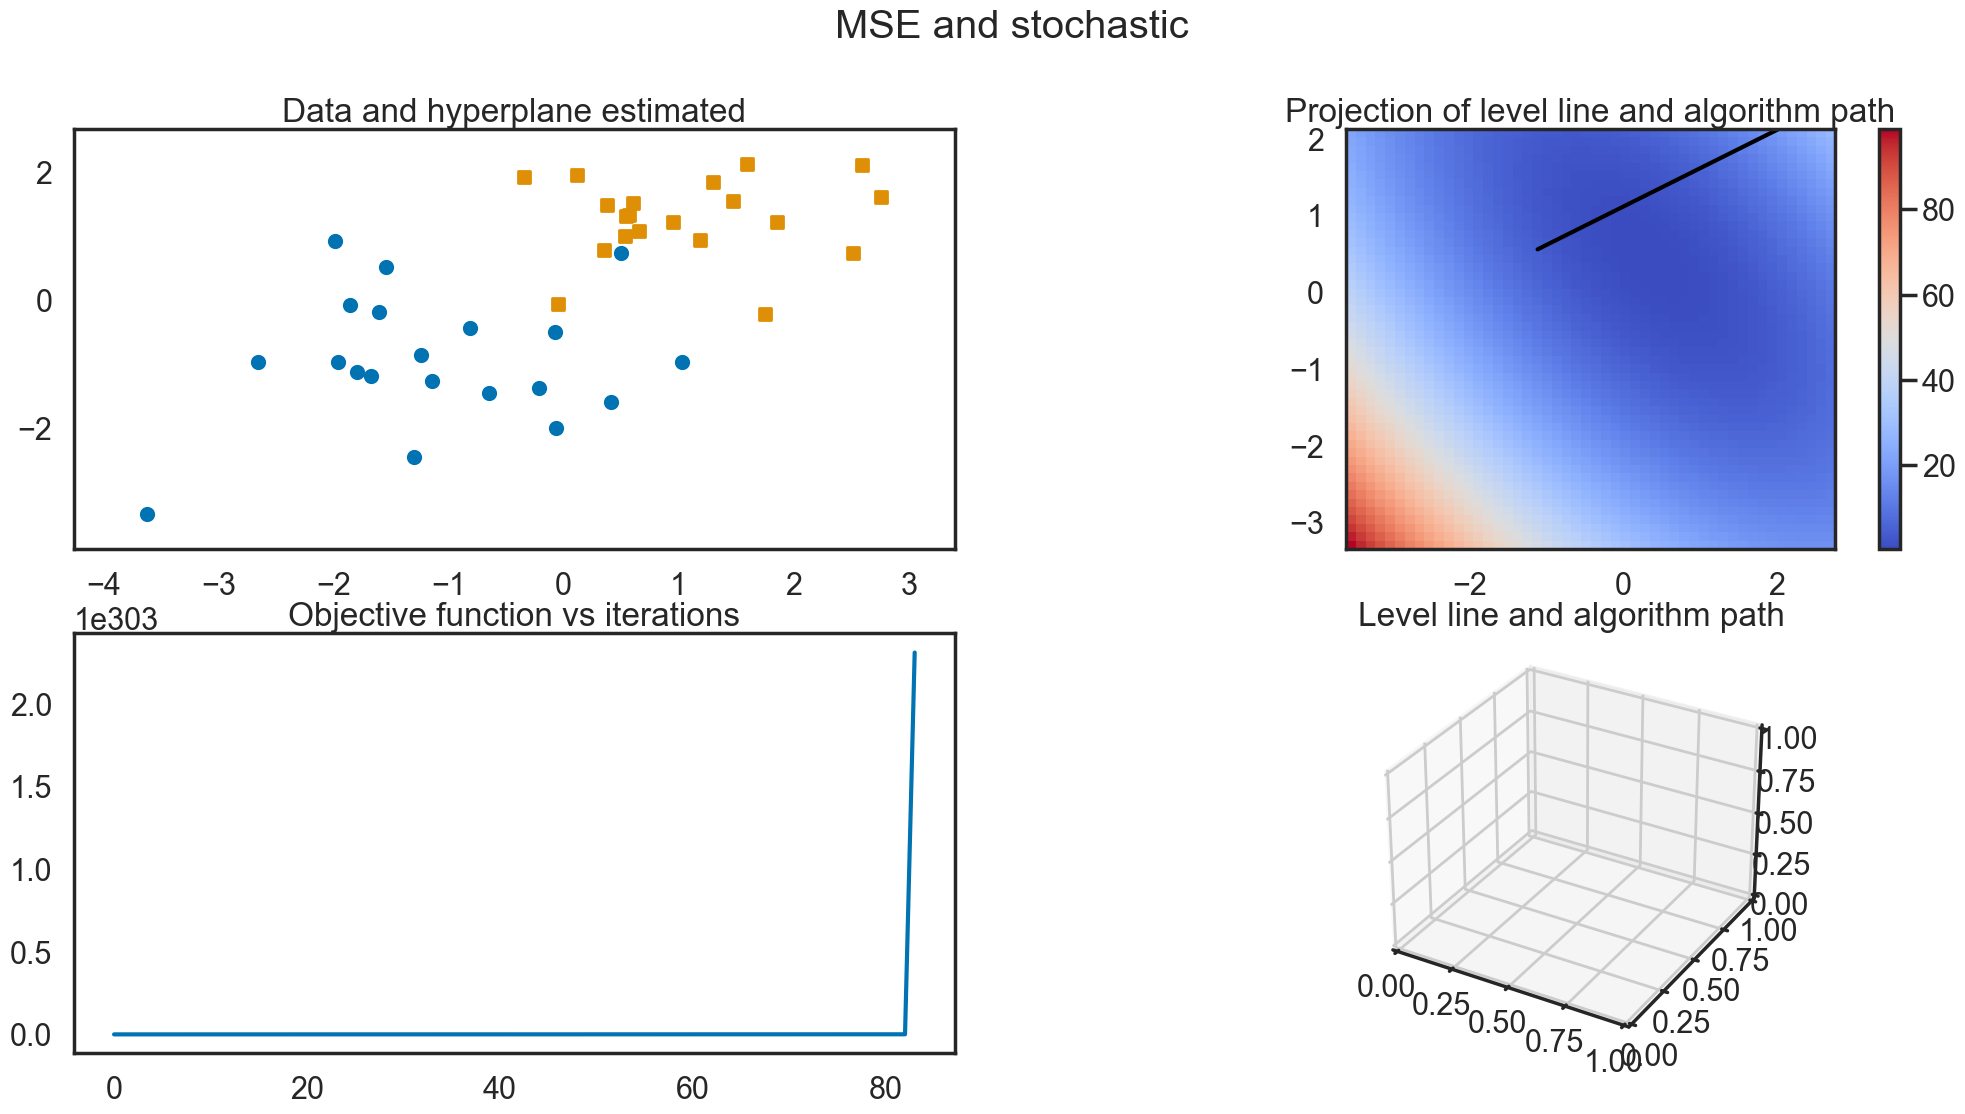

In [70]:
eps = 0.25
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=False)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

### 7.2. Simulation avec la difficulté de classification de données (nature des données)

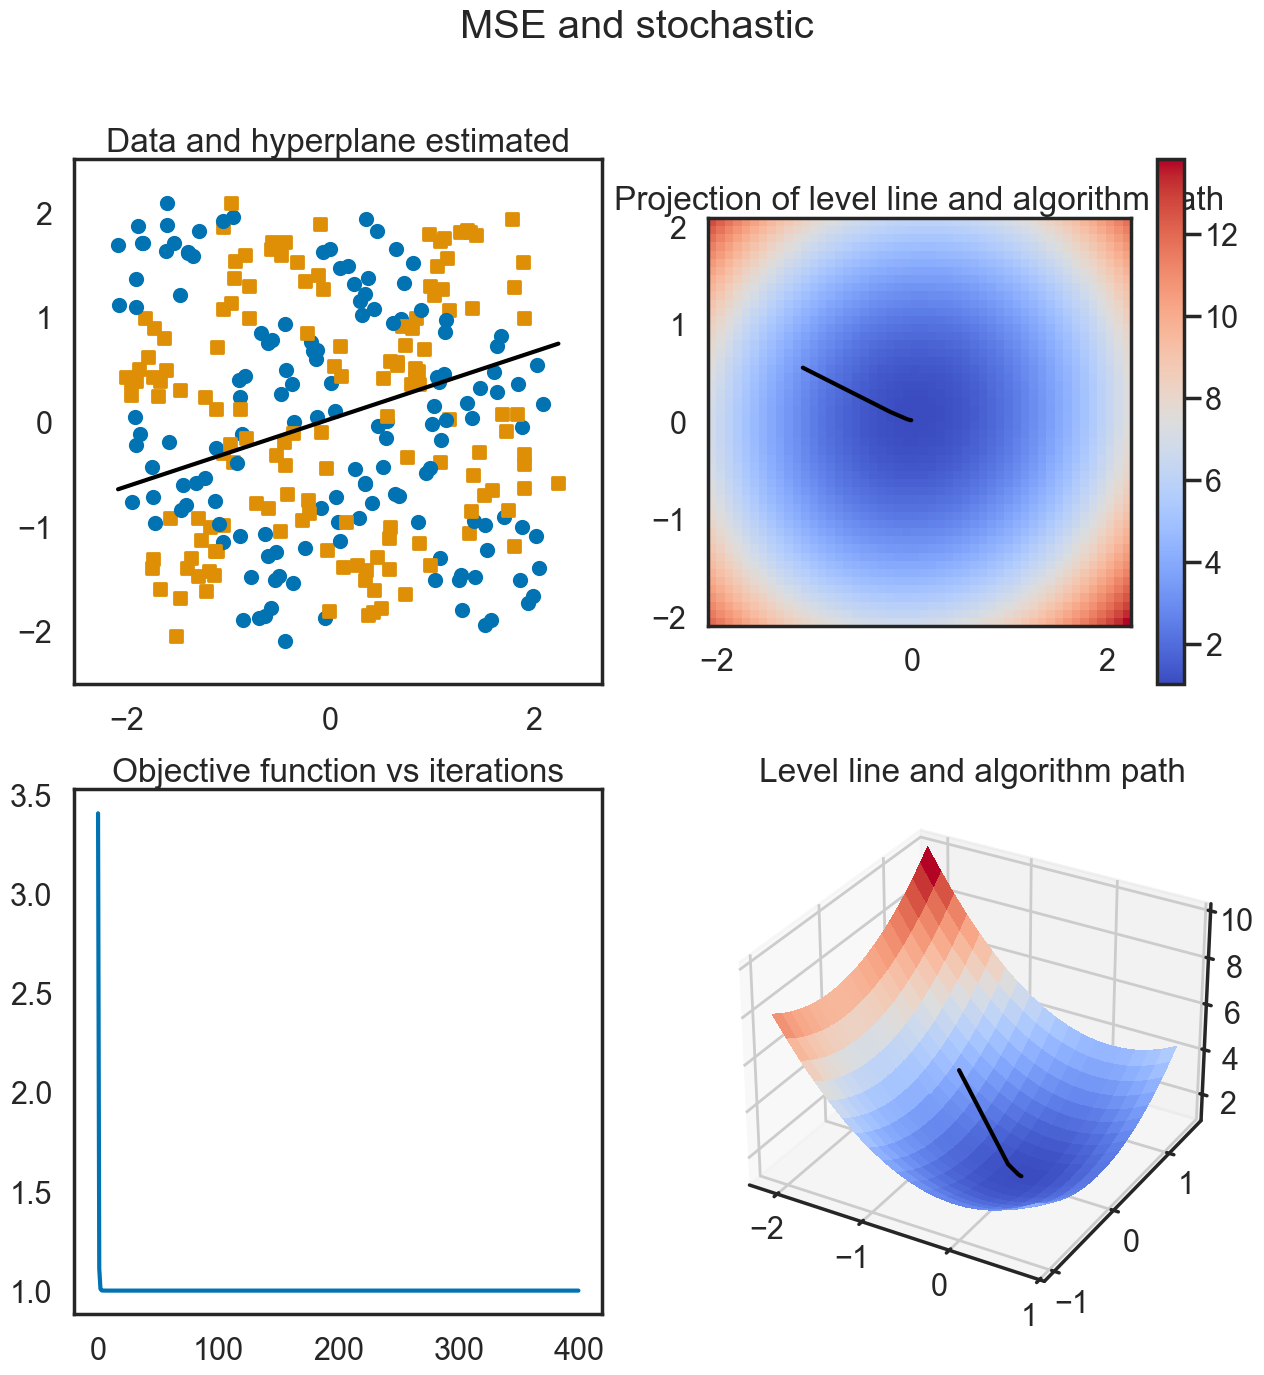

In [71]:
eps = 0.001
plt.figure(7, figsize=(15, 15))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient(X_chekers, Y_chekers, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=False)
plot_gradient(X_chekers, Y_chekers, wh_sto, costh_sto, loss_fun)

# 9. Proposition des variantes de conditions d'arrêt de l'algorithme

### **Condition 1 : nombre d'itérations**

Comme nous l'avons fait, on fixe un **nombre d'itérations égal à 10**.  
Voici donc la condition utilisée :

$$
k = K_{\text{max}}
$$

où :  
- \( k \) est le **nombre d’itérations actuel**  
- \( K_{\text{max}} \) est le **nombre maximal d’itérations**

### **Condition 2 : tolérance sur la perte**

La condition est la suivante :

$$
\left( \mathcal{J}(\theta^{(k)}) - \mathcal{J}(\theta^{(k-1)}) \right) < \epsilon
$$

Cela signifie que les **deux dernières valeurs de la fonction de perte**  
s'améliorent de façon **très faible**, c’est-à-dire que la variation est inférieure à un seuil $\epsilon$.

### **Condition 3 : tolérance sur les paramètres**

La condition est la suivante :

$$
\left\| \theta^{(k)} - \theta^{(k-1)} \right\| < \epsilon
$$

Cela signifie que la **distance entre les deux vecteurs de paramètres successifs**  
ne s'améliore **plus que très faiblement**, indiquant une forme de **stagnation**.

### Programmation de la tolérance sur la perte

In [73]:
def gradient_1(x, y, eps, niter, w_ini, loss_fun, gr_loss_fun, threshold=1e-5, stochastic=True):
    """ Algorithme de descente du gradient :
        - x : donnees
        - y : label
        - eps : facteur multiplicatif de descente
        - niter : nombre d'iterations
        - w_ini
        - loss_fun : fonction de cout
        - gr_loss_fun : gradient de la fonction de cout
        - threshold : seuil de la norme du gradient pour la convergence
        - stochastic : True : gradient stochastique
    """
    w = np.zeros((niter, w_ini.size))
    w[0] = w_ini
    loss = np.zeros(niter)
    loss[0] = loss_fun(x, y, w[0]).mean()
    
    for i in range(1, niter):
        if stochastic:  # this is for Stochastic Gradient Descent
            idx = [np.random.randint(x.shape[0])]
        else:           # this is for pure Gradient Descent
            idx = np.arange(x.shape[0])
        
        # Calculate the gradient
        gradient_vector = gr_loss_fun(x[idx, :], y[idx], w[i - 1, :])
        
        # Check the norm of the gradient for convergence
        if np.linalg.norm(gradient_vector) <= threshold:
            print(f"Converged at iteration {i}. Norm of gradient: {np.linalg.norm(gradient_vector)}")
            break  # Stop the loop if the norm of the gradient is below the threshold
        
        # Update the weights
        w[i, :] = w[i - 1, :] - eps * gradient_vector
        
        # Calculate and store the loss
        loss[i] = loss_fun(x, y, w[i, :]).mean()
    
    return w[:i+1], loss[:i+1]

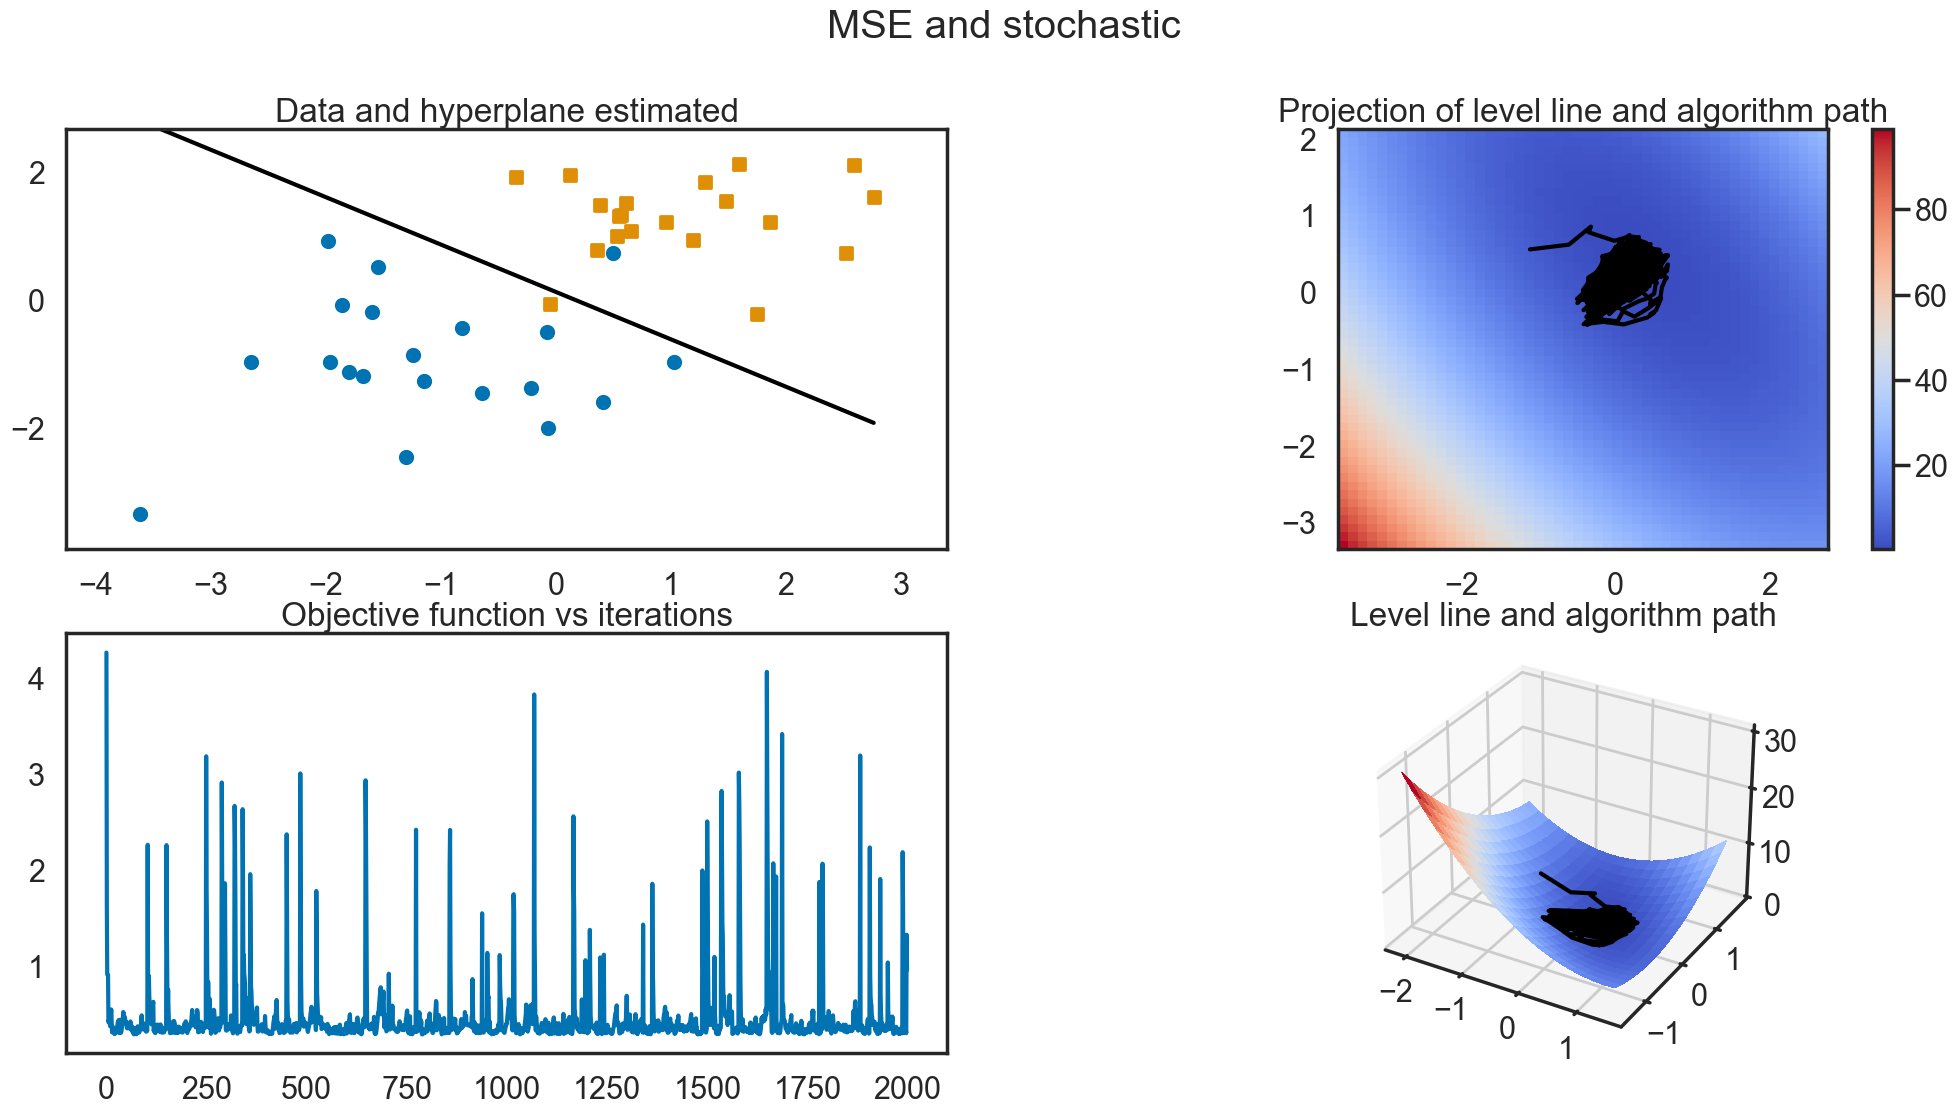

In [74]:
eps = 0.05
niter = 50
plt.figure(8, figsize=(25, 12))
plt.suptitle('MSE and stochastic')
wh_sto, costh_sto = gradient_1(X_bi_gauss, Y_bi_gauss, eps, niter * len(Y_bi_gauss), w_ini, loss_fun,
                             gr_lfun, stochastic=True)
plot_gradient(X_bi_gauss, Y_bi_gauss, wh_sto, costh_sto, loss_fun)

# 10. évolution des frontières en fonctions des itérations

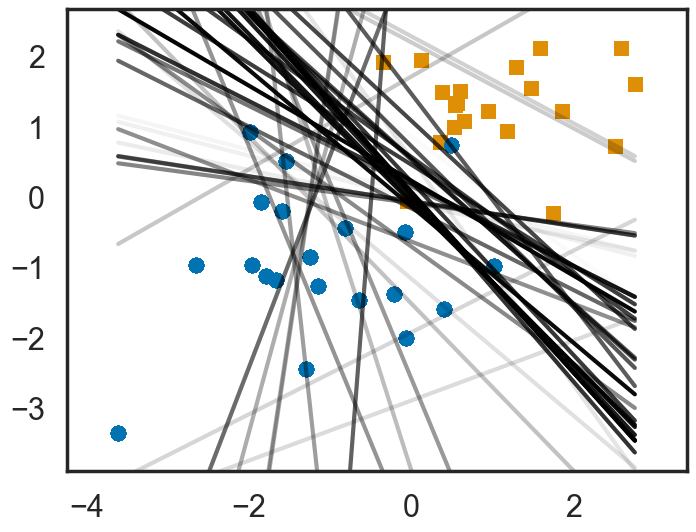

In [80]:
eps = 0.1
w_ini = np.random.randn(X_bi_gauss.shape[1] + 1)
loss_fun = mse_loss
gr_lfun = gr_mse_loss

plt.figure(11)
wh_sto, costh_sto = gradient(X_bi_gauss, Y_bi_gauss, eps, niter, w_ini, loss_fun,
                             gr_lfun, stochastic=True)
indexess = np.arange(0., 1, 1. / float(niter))
for i in range(niter):
    plot_2d(X_bi_gauss, Y_bi_gauss, wh_sto[i, :], alpha_choice=indexess[i])

# 12. Formules

**Ellipse :**

$$
\frac{x^2}{a^2} + \frac{y^2}{b^2} = 1
$$

**Hyperparabole :**

$$
\frac{x^2}{a^2} - \frac{y^2}{b^2} = 1
$$

**Parabole :**

$$
y = ax^2 + bx + c
$$